# Team Data Ducks — G2: Project Prototype

**Members:**  
– Nikhaz Omar     
– Shayan Sooratgar  
– Tiffany von Streng

**Repository (private):** *GitHub / GitLab URL*

### Contributions
- **Nikhaz Omar:** Backend, Frontend, video creation
- **Shayan Sooratgar:** Frontend, worldmap creation
- **Tiffany von Streng:** Data processing, wrangling, and figure creation

---

### Tool Task List
1. Explore temporal development and trends of SDG scores per country.  
2. Explore relations between SDG scores and external attributes such as forest area or type of government.  
3. Compare SDG performance across countries in a given year or time period.  
4. Identify patterns and outliers in SDG–external attribute relations across countries and over time.

---

## Attribute Overview (Data Types)

| Attribute | Description | Type |
|----------|-------------|------|
| Country | Territory name | Categorical |
| Year | Reference year | Numeric (discrete) |
| Political Stability | LLM-derived score (0–100) | Numeric |
| Ethnic Fractionalization | LLM-derived (0–100) | Numeric |
| Media Freedom | LLM-derived (0–100) | Numeric |
| Discrimination Level | LLM-derived (0–100) | Numeric |
| Religiosity Level | LLM-derived (0–100) | Numeric |
| Forest Area (%) | Forest share of land area | Numeric |
| SDG Index Score | Composite SDG score (0–100) | Numeric |
| Goal 1–17 Scores | SDG scores (0–100) | Numeric |


## Distribution Tables

We chose to present Goals 1 and 17 scores and not the scores for all Goals.

We selected **six representative countries** per attribute:

- Two with the **lowest** values  
- Two with the **highest** values  
- One with the **largest year-to-year increase**  
- One with the **largest year-to-year decrease**

This selection illustrates:

- distribution extremes  
- variation across time  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


PATH = "run_31_reduced.csv"

ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_17_score",
]


def load_cols(path, cols):
    usecols = ["country", "year"] + cols
    df = pd.read_csv(path, usecols=usecols)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def yearly_quantiles(df, col, qs=(0.10, 0.25, 0.50, 0.75, 0.90)):
    g = (
        df.dropna(subset=[col, "year"])
          .assign(year=lambda x: x["year"].astype(int))
          .groupby("year")[col]
          .quantile(qs)
          .unstack()
          .sort_index()
    )
    g.columns = [f"q{int(q*100)}" for q in qs]
    return g


def pick_representatives(
    df,
    col,
    n_low=2,
    n_high=2,
    n_up=1,
    n_down=1,
    min_values_per_country=3, 
):

    g = df.dropna(subset=[col, "year"]).copy()
    if g.empty:
        return []

    g["year_i"] = g["year"].astype(int)


    # keep only countries with enough real values
    valid_counts = g.groupby("country")[col].count()
    keep_countries = valid_counts[valid_counts >= min_values_per_country].index
    g = g[g["country"].isin(keep_countries)]

    if g.empty:
        return []

    # level-based representatives (low vs high mean)
    mean_lvl = g.groupby("country")[col].mean().sort_values()
    lows  = list(mean_lvl.head(n_low).index)
    highs = list(mean_lvl.tail(n_high).index)

    # slope-based representatives (strongest up / down trends)
    def slope(gr):
        gg = gr.dropna(subset=[col, "year_i"]).sort_values("year_i")
        if gg["year_i"].nunique() < 2:
            return np.nan
        x = gg["year_i"].to_numpy()
        y = gg[col].to_numpy()
        return np.polyfit(x, y, 1)[0]

    sl = g.groupby("country").apply(slope).dropna()
    if sl.empty:
        reps = list(dict.fromkeys(lows + highs))
        return reps

    ups   = list(sl.sort_values(ascending=False).head(n_up).index)
    downs = list(sl.sort_values().head(n_down).index)

    reps = list(dict.fromkeys(lows + highs + ups + downs))
    return reps


def plot_ribbon_with_reps(df, col, reps, title=None):
    qtab = yearly_quantiles(df, col)
    fig, ax = plt.subplots(figsize=(11, 6))

    # --- background distribution (unchanged) ---
    if not qtab.empty:
        years = qtab.index.values
        if "q10" in qtab and "q90" in qtab:
            ax.fill_between(years, qtab["q10"], qtab["q90"], alpha=0.12, label="P10–P90")
        if "q25" in qtab and "q75" in qtab:
            ax.fill_between(years, qtab["q25"], qtab["q75"], alpha=0.20, label="IQR (P25–P75)")
        if "q50" in qtab:
            ax.plot(years, qtab["q50"], linewidth=2.1, color="k", label="Median")

    # tidy data
    g = (
        df.dropna(subset=[col, "year"])
          .assign(year_i=lambda x: x["year"].astype(int))
          .sort_values(["country", "year_i"])
    )

    # --- compute small vertical jitter for identical series among reps ---
    # pivot to country-wise series
    g_rep = g[g["country"].isin(reps)]
    if not g_rep.empty:
        pivot = g_rep.pivot(index="year_i", columns="country", values=col)

        # round a bit to avoid floating-point noise
        pivot_rounded = pivot.round(6)

        # identify duplicates by signature (tuple of values per year)
        pattern_counts = {}   # signature -> how many already seen
        offsets = {}          # country -> jitter index (0,1,2,...)

        for c in reps:
            if c not in pivot_rounded.columns:
                offsets[c] = 0
                continue
            series = tuple(pivot_rounded[c].fillna(np.nan).values)
            k = pattern_counts.get(series, 0)
            offsets[c] = k
            pattern_counts[series] = k + 1

        # base jitter size as fraction of value range
        if g[col].notna().any():
            y_min, y_max = g[col].min(), g[col].max()
            y_range = y_max - y_min if y_max > y_min else 1.0
        else:
            y_range = 1.0
        y_jitter = 0.01 * y_range  # 1% of range
    else:
        offsets = {c: 0 for c in reps}
        y_jitter = 0.0

    # --- plot representative countries with jitter if needed ---
    for c in reps:
        gi = g[g["country"] == c]
        if gi.empty or gi[col].isna().all():
            continue

        offset = offsets.get(c, 0) * y_jitter
        ax.plot(
            gi["year_i"],
            gi[col] + offset,  # apply vertical jitter
            linewidth=1.6,
            marker="o",
            markersize=3,
            label=c,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel(col)
    ax.set_title(title or f"{col} — distribution + representative countries")
    ax.grid(True, alpha=0.35)
    if reps:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Selected countries")
    plt.tight_layout()
    plt.show()

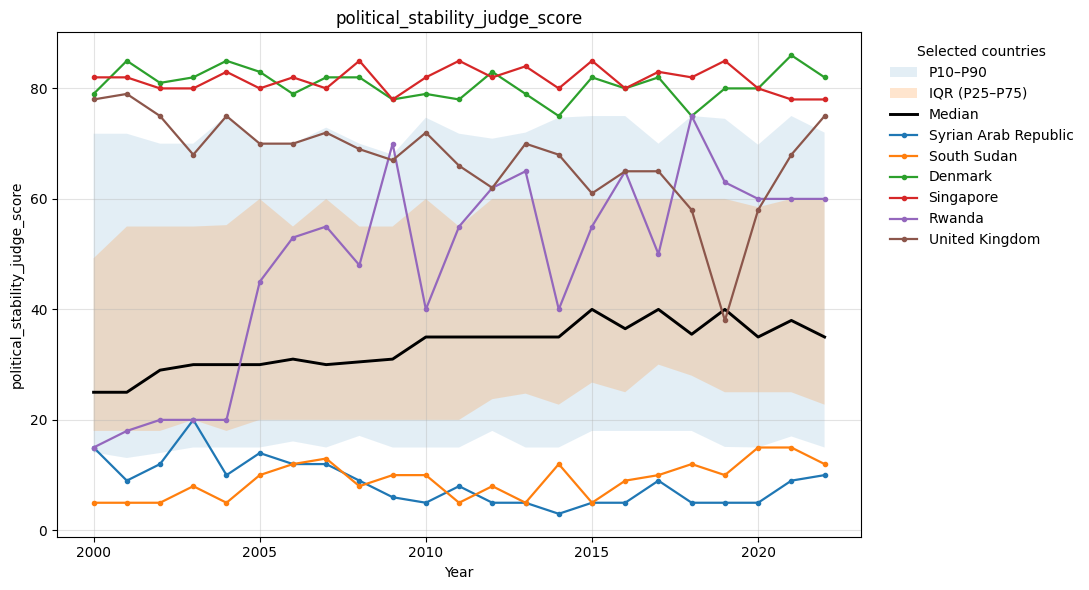

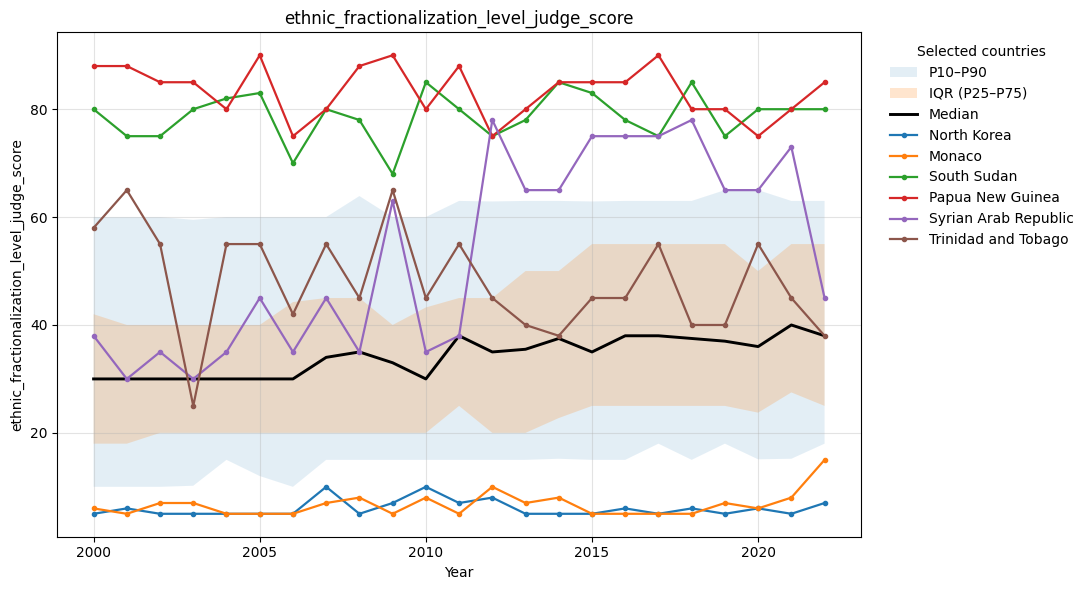

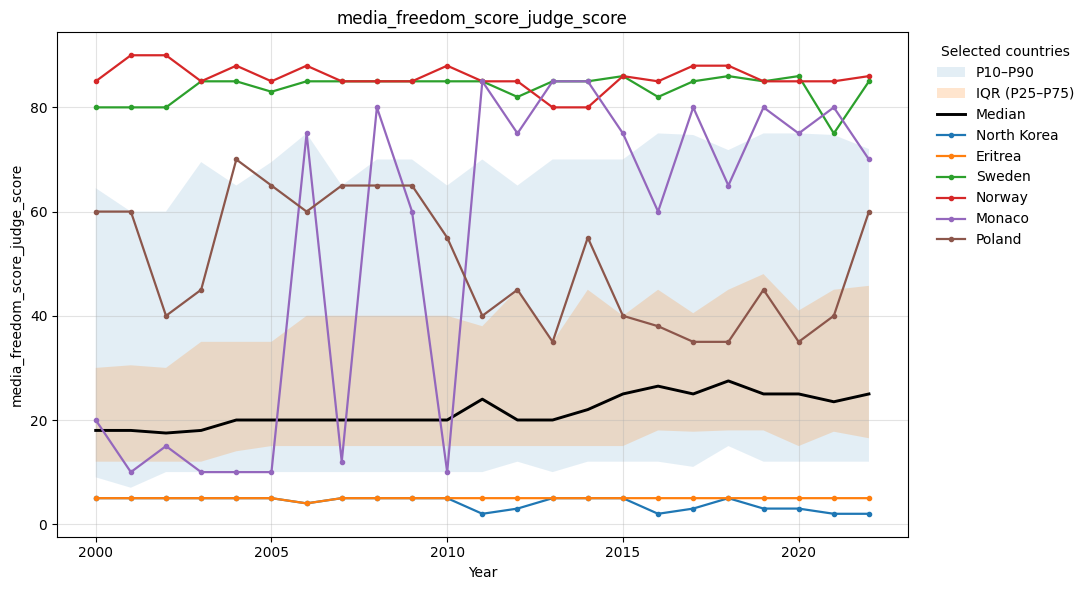

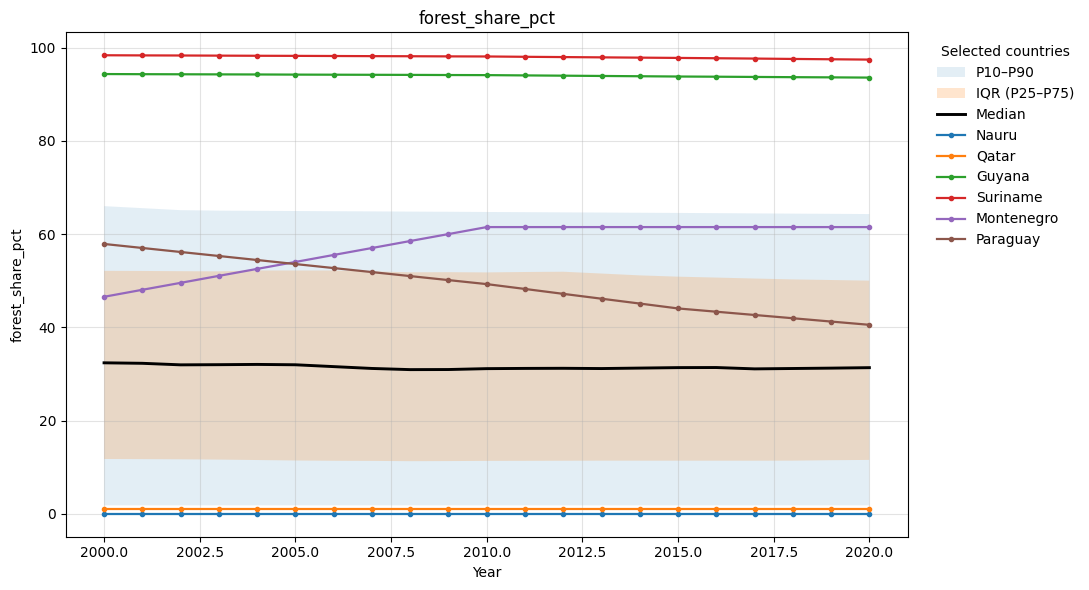

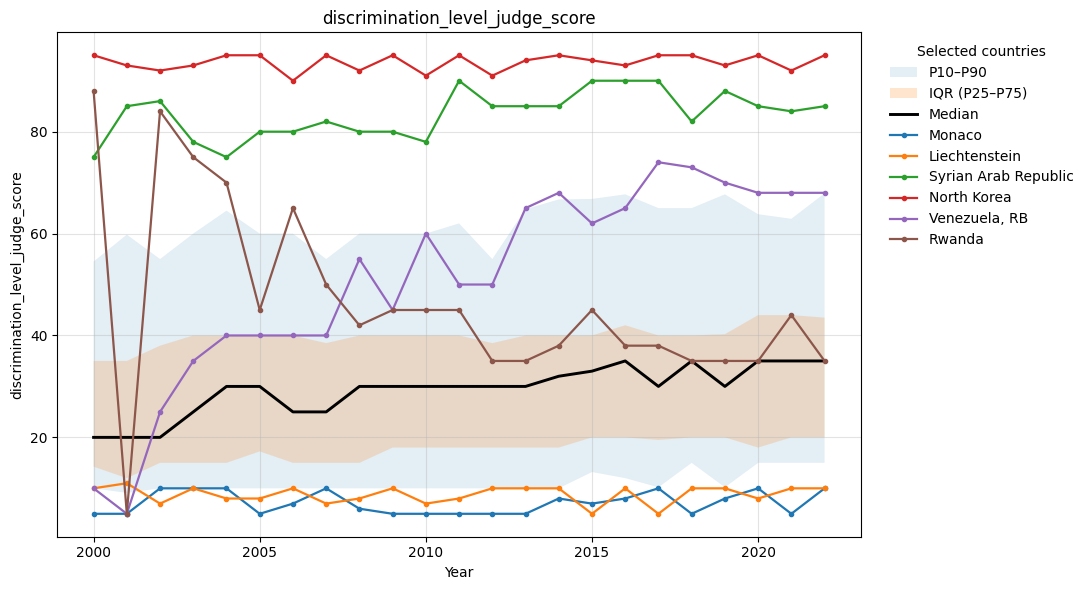

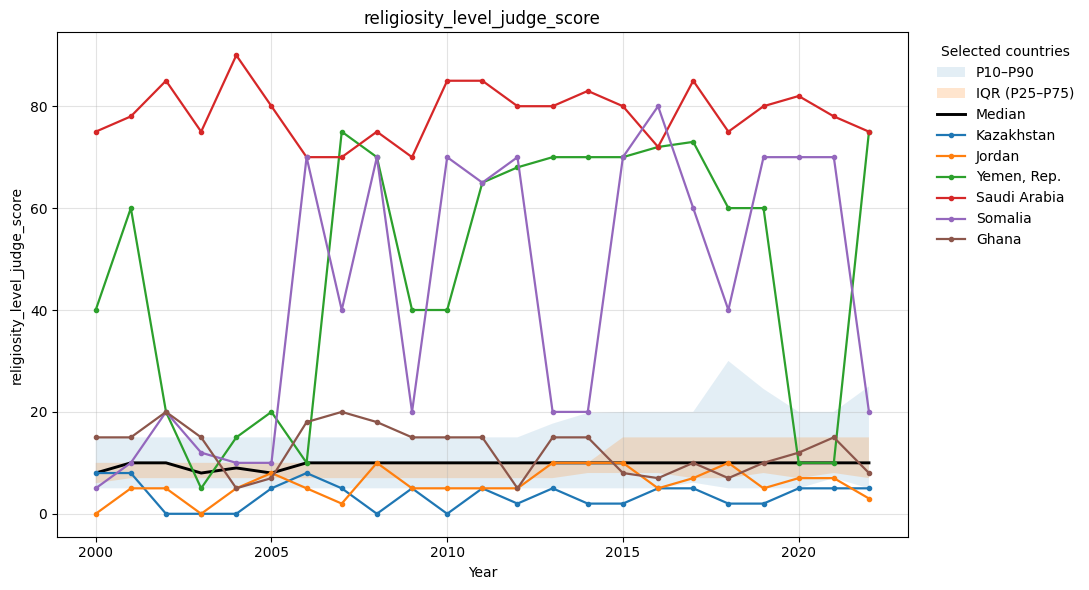

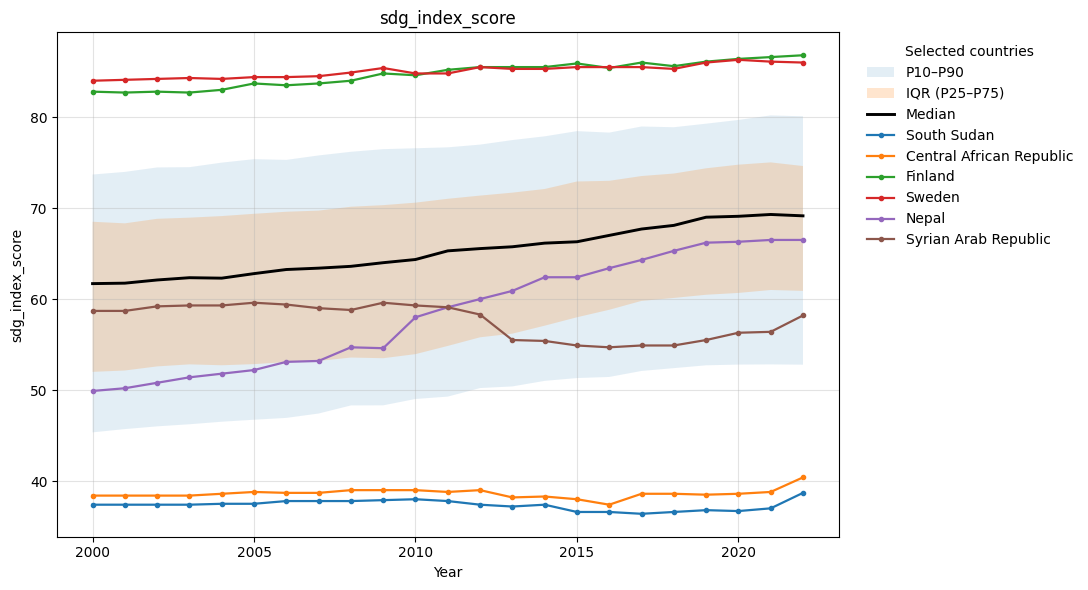

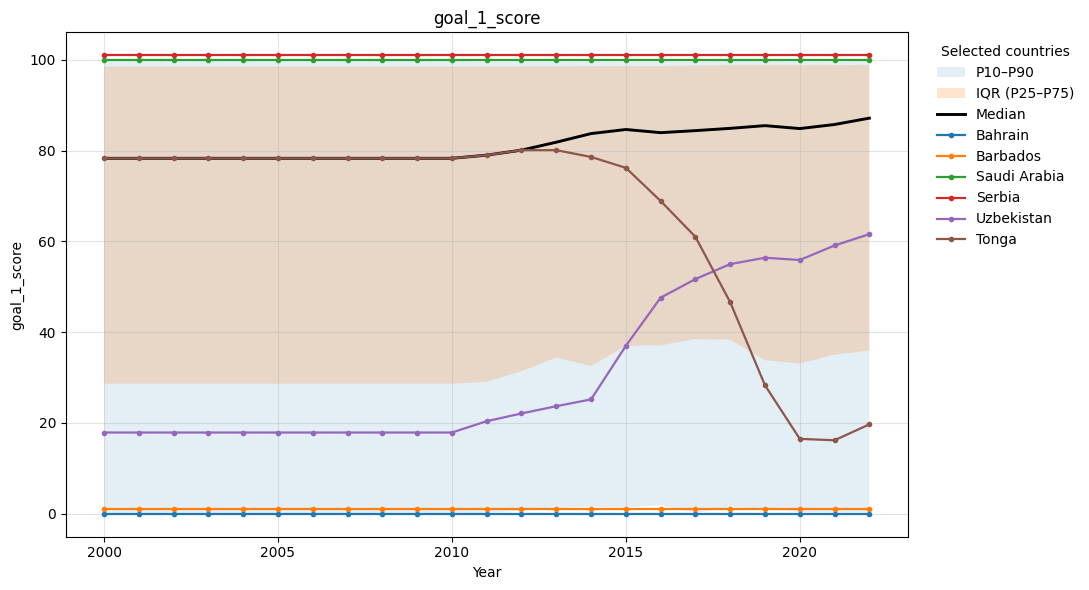

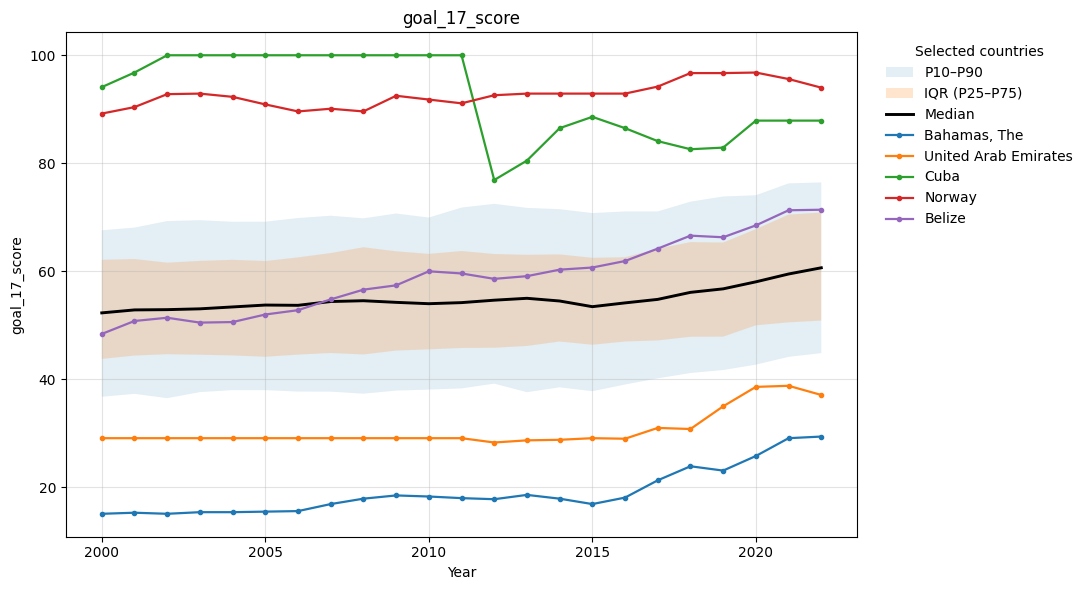

In [11]:


f = load_cols(PATH, ATTRS)
for col in ATTRS:
    reps = pick_representatives(f, col)
    # Do not print representatives in PDF
    plot_ribbon_with_reps(f, col, reps, title=col)


## Year-by-Year Distribution Plots

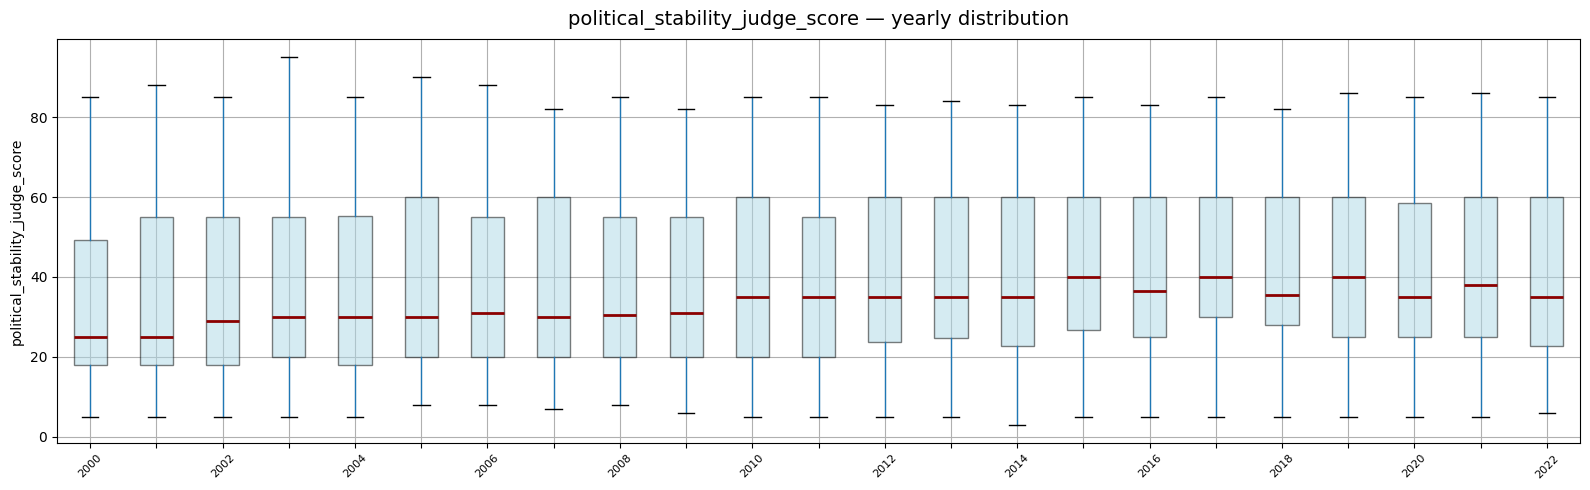

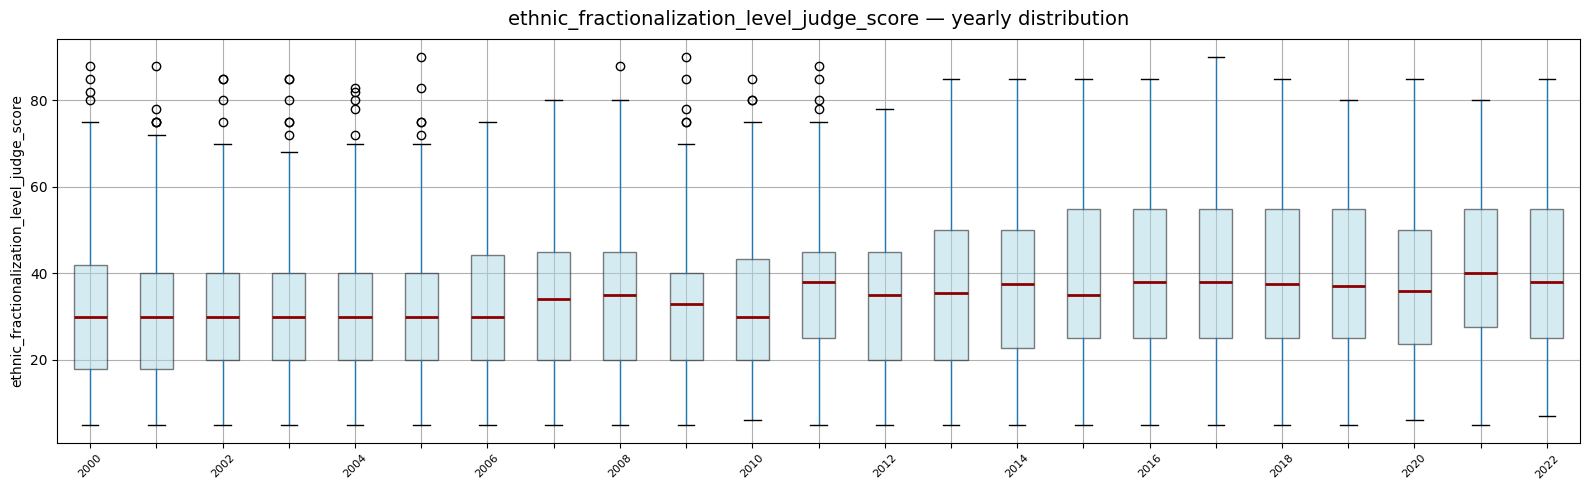

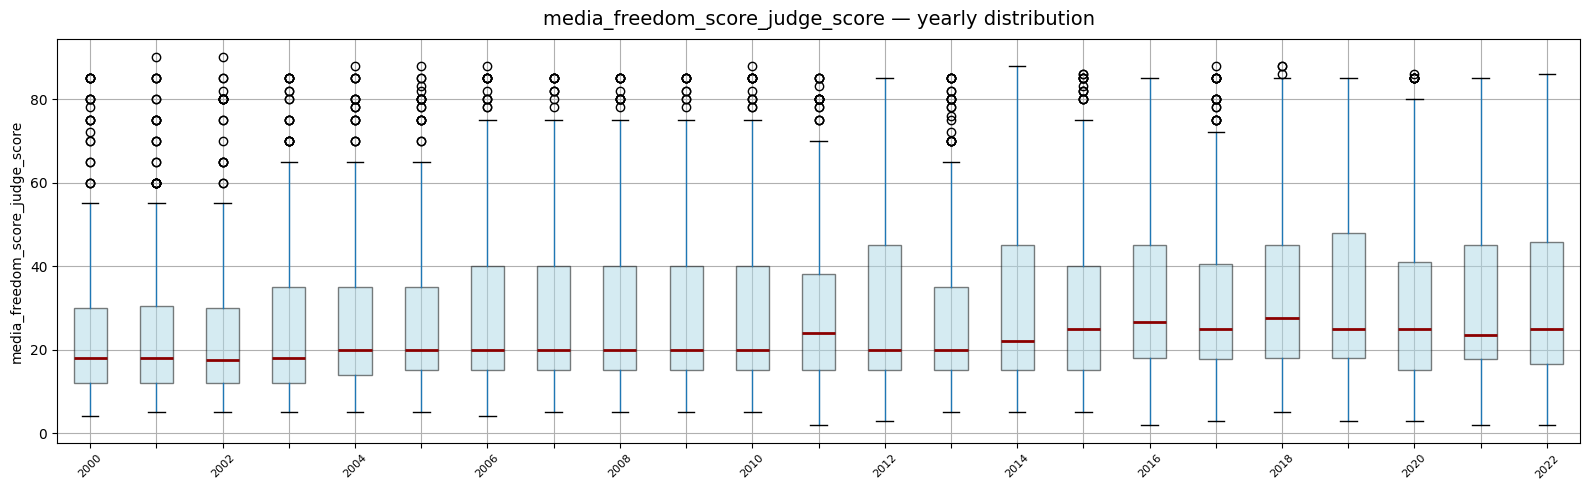

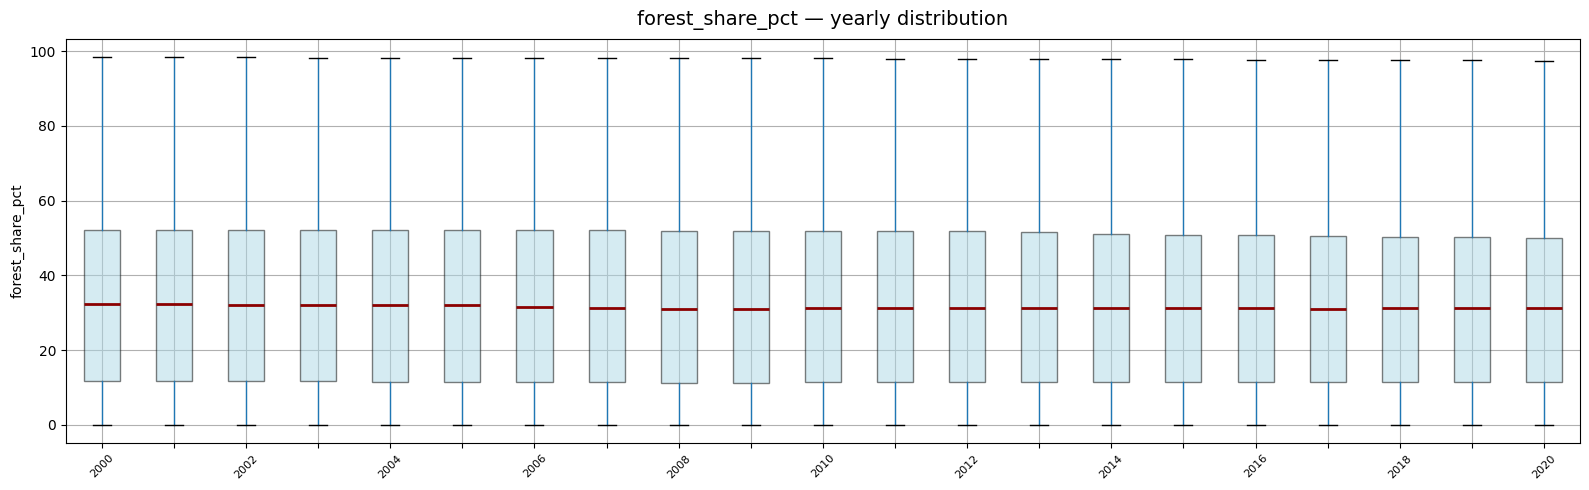

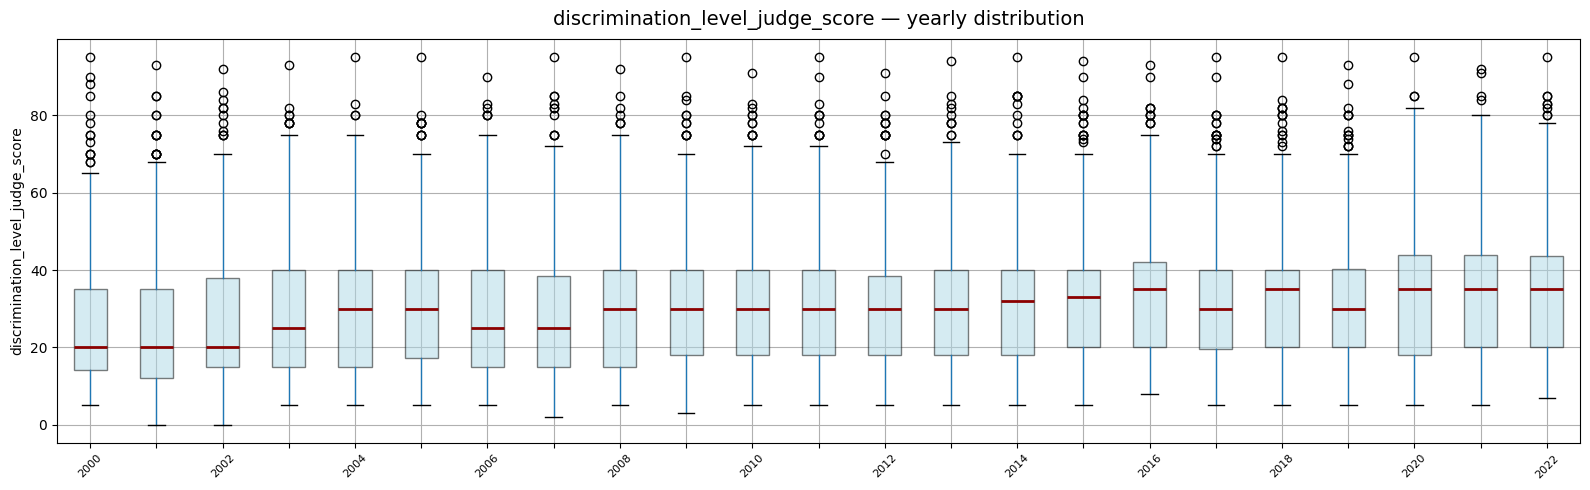

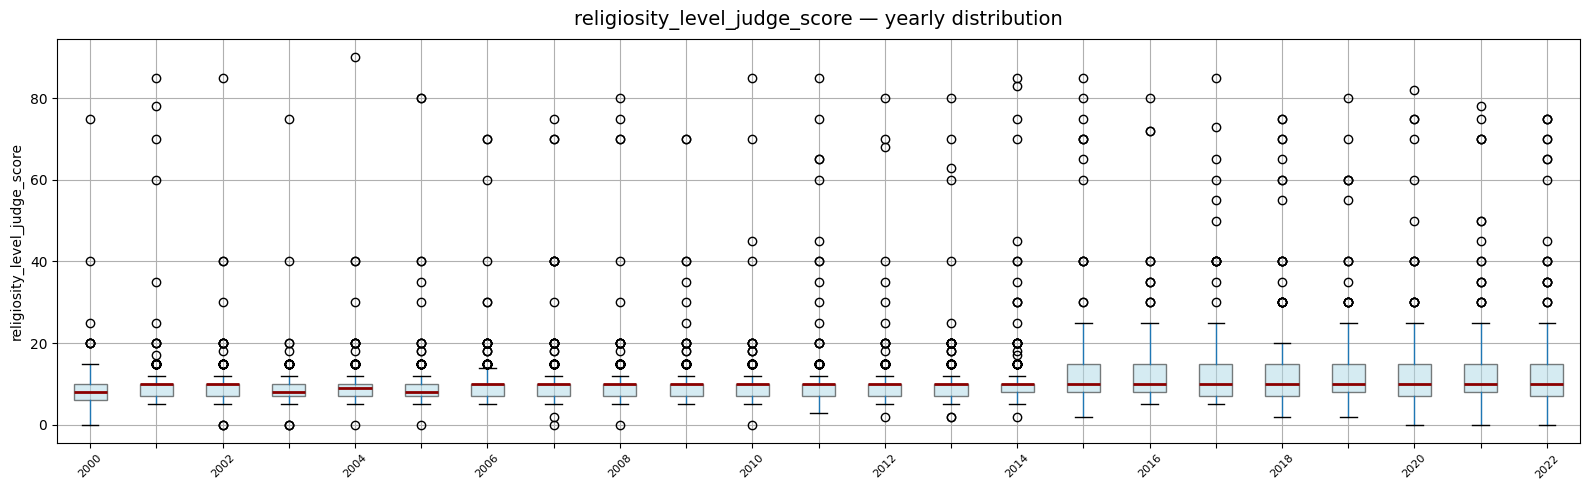

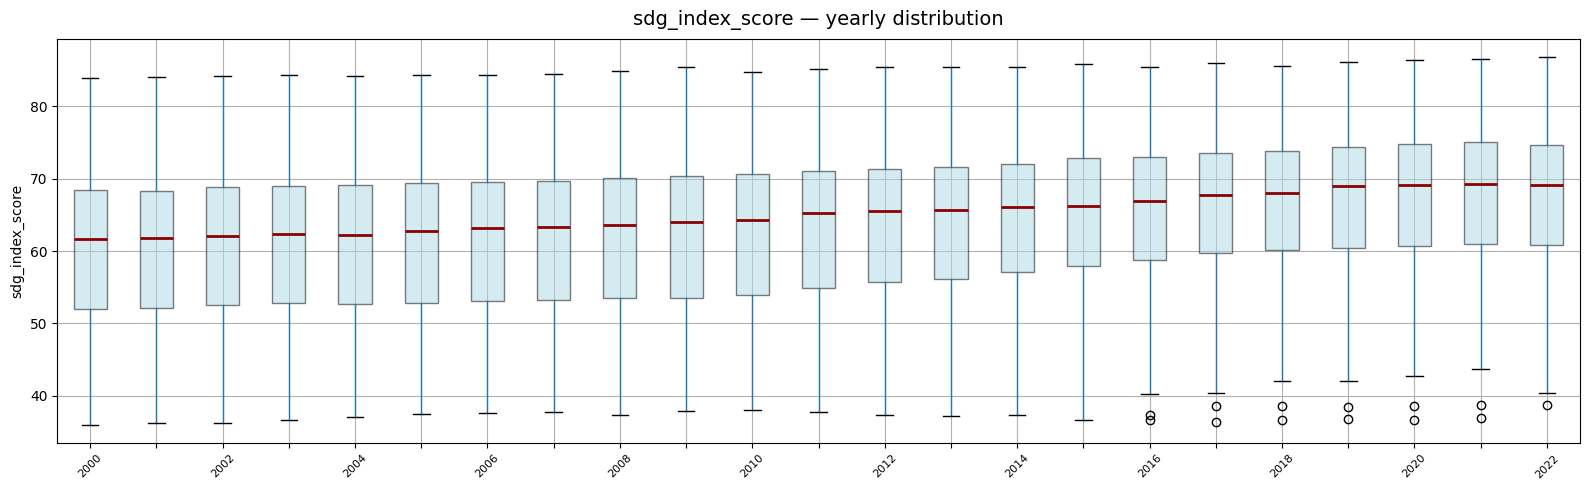

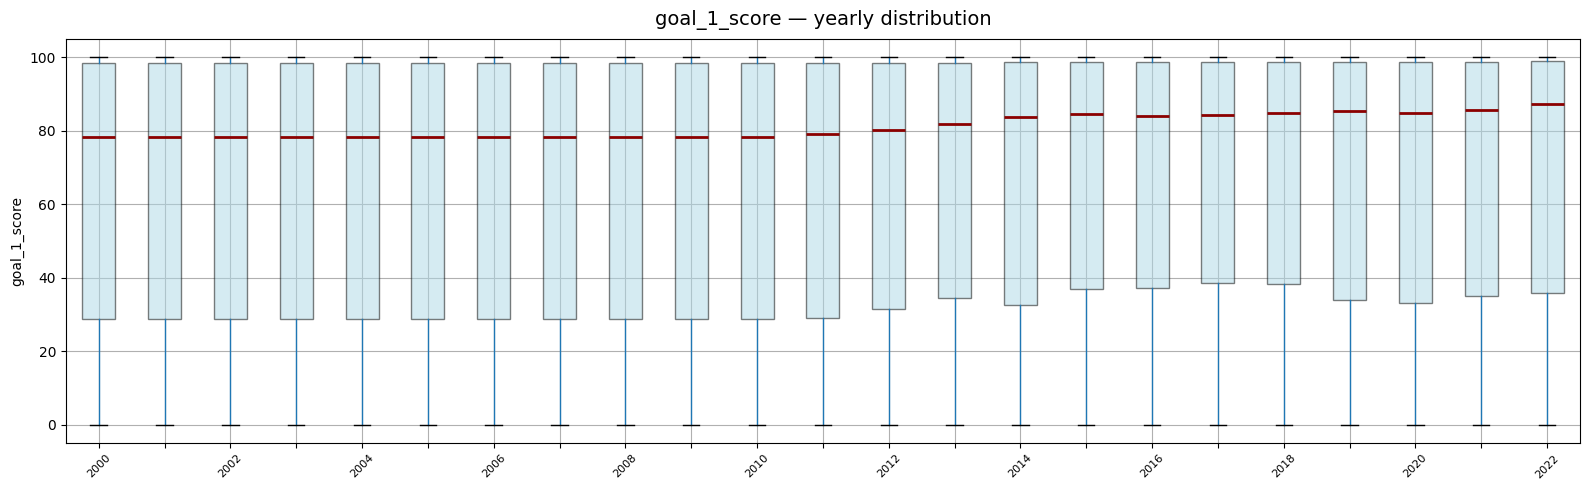

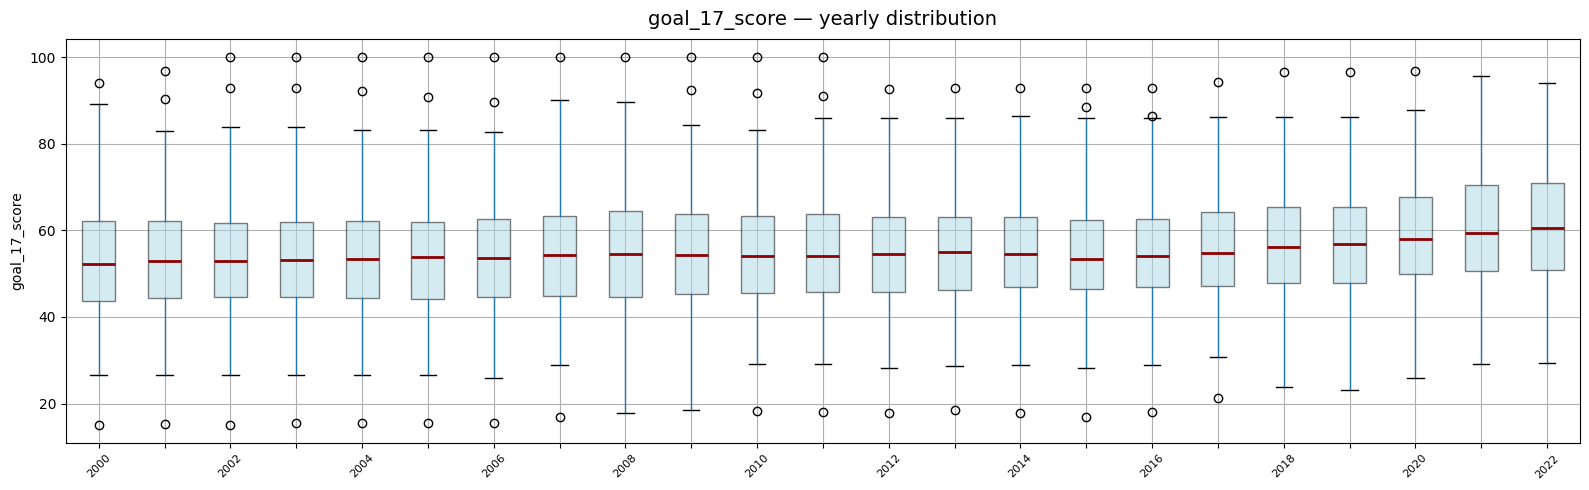

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("run_31_reduced.csv")

# All numeric attributes you want distributions for
DIST_ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_17_score",
]

df["year"] = df["year"].astype(int)

def plot_yearly_distribution(df, col):
    tmp = df[["year", col]].dropna()

    # Pivot: each column is one year (improves spacing)
    pivot = tmp.pivot(columns="year", values=col)

    # Plot
    plt.figure(figsize=(16, 5))
    box = pivot.boxplot(
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", alpha=0.5),
        medianprops=dict(color="darkred", linewidth=2),
    )

    plt.title(f"{col} — yearly distribution", fontsize=14, pad=10)
    plt.ylabel(col)

    # Show only every 2nd year to avoid overcrowding
    ticks = plt.xticks()[0]
    labels = [int(l.get_text()) for l in plt.gca().get_xticklabels()]
    for i, label in enumerate(plt.gca().get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        label.set_rotation(45)
        label.set_fontsize(8)

    plt.tight_layout()
    plt.show()

for col in DIST_ATTRS:
    plot_yearly_distribution(df, col)


## Information of each (relevant) attribute’s data quality

**Missing values** 

No missing values in LLM generated data or SDG goals. First to be expected because just generated for all given countries. For SDG goals no missing values in dataset, because we deleted the countries that are only in the forest share dataset and kept only the countries from the sdg index. Missing values in forest share because we have no values for the years 2021 and 2022. This is coherent with our forest data set, we might want to interpolate for those years later on,but for now it is sufficient.  

**Outliers**  
Outliers (Q1-1.5 x IQR and Q3+1.5 x IQR) occur in some attributes, but are all within range and plausible given our data.

**Consistency**  
No duplicate country–year rows with conflicting values were found. All attributes are internally consistent.

**Validity**  
All values lie within expected ranges (0–100). Missingness only in forest_share_pct and 9.65%. We might question the validity of some of our LLM generated data, because we have a notable number of big jumps in political stability (31), media freedom (30) and religosity level (41). While those are possible (e.g. start of a war, change of regime to more authoritarian) the number of them seems high. 



In [41]:
import pandas as pd
import numpy as np

PATH = "run_31_reduced.csv"

ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_2_score",
    "goal_3_score",
    "goal_4_score",
    "goal_5_score",
    "goal_6_score",
    "goal_7_score",
    "goal_8_score",
    "goal_9_score",
    "goal_10_score",
    "goal_11_score",
    "goal_12_score",
    "goal_13_score",
    "goal_14_score",
    "goal_15_score",
    "goal_16_score",
    "goal_17_score",
]

# Validity bounds (default 0–100)
BOUNDS = {a: (0, 100) for a in ATTRS}
BOUNDS["forest_share_pct"] = (0, 100)

df = pd.read_csv(PATH)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# convert all ATTRS to numeric
for col in ATTRS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def iqr_outliers(series):
    """Return lower_fence, upper_fence, count_outliers using Q1-1.5IQR rule."""
    s = series.dropna()
    if len(s) < 5:
        return (np.nan, np.nan, 0)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = int(((s < low) | (s > high)).sum())
    return (low, high, n_out)

results = []

for col in ATTRS:
    s = df[col]
    lo, hi = BOUNDS[col]

    missing = int(s.isna().sum())
    missing_pct = round(100 * missing / len(s), 2)

    invalid_low  = int((s < lo).sum())
    invalid_high = int((s > hi).sum())

    low_fence, high_fence, n_out = iqr_outliers(s)

    # consistency: large jumps year-over-year (>40 points)
    jumps = 0
    if "year" in df.columns:
        for c, g in df[["country", "year", col]].dropna().groupby("country"):
            g = g.sort_values("year")
            delta = g[col].diff().abs()
            jumps += int((delta > 40).sum())

    # duplicates (conflicting country-year values)
    dups = df.groupby(["country", "year"])[col].nunique()
    inconsist = int((dups > 1).sum())

    results.append({
        "attribute": col,
        "missing": missing,
        "missing_%": missing_pct,
        "invalid_low": invalid_low,
        "invalid_high": invalid_high,
        "iqr_lower_fence": None if pd.isna(low_fence) else round(low_fence, 2),
        "iqr_upper_fence": None if pd.isna(high_fence) else round(high_fence, 2),
        "outliers_IQR_rule": n_out,
        "large_jumps": jumps,
        "duplicate_conflicts": inconsist
    })

dq = pd.DataFrame(results)
dq


,attribute,missing,missing_%,invalid_low,invalid_high,iqr_lower_fence,iqr_upper_fence,outliers_IQR_rule,large_jumps,duplicate_conflicts
0,political_stability_judge_score,0,0.00,0,0,-40.00,120.00,0,31,0
1,ethnic_fractionalization_level_judge_score,0,0.00,0,0,-17.50,82.50,31,7,0
2,media_freedom_score_judge_score,0,0.00,0,0,-22.50,77.50,299,30,0
3,forest_share_pct,426,9.65,0,0,-49.01,112.06,0,0,0
4,discrimination_level_judge_score,0,0.00,0,0,-15.00,73.00,257,9,0
5,religiosity_level_judge_score,0,0.00,0,0,2.50,14.50,1038,41,0
6,sdg_index_score,0,0.00,0,0,31.65,96.05,0,0,0
7,goal_1_score,0,0.00,0,0,-68.96,199.14,0,0,0
8,goal_2_score,0,0.00,0,0,33.05,84.65,131,0,0
9,goal_3_score,0,0.00,0,0,-6.55,134.05,0,0,0



## Information on goals: what we need to visualize and model with this data and what it takes to prepare our data for those goals

**General Goal** : Build a coherent, merged country–year dataset combining SDG scores, LLM-derived indicators, and forest data to support analysis and modeling.

**Task 1**: Visualize SDG trends; model simple time trends. Requires numeric SDG values and consistent years.

**Task 2**: Visualize SDG vs. LLM scores and forest share; model regressions. Requires merging and interpolating forest data.

**Task 3**: Visualize rankings and regional patterns; model clustering. Requires region labels and reference years.

**Task 4**: Visualize SDG–attribute relations over time and show patterns and outliers; model regressions and correlation. Requires region labels and other country groupings.

## Visualizations to appropriately and clearly present the data wrangling progress
 1. Flow chart of data wrangling
 2. Forest Area raw vs. linearly interpolated (two example countries)
 3. country name matching before and after harmonisation

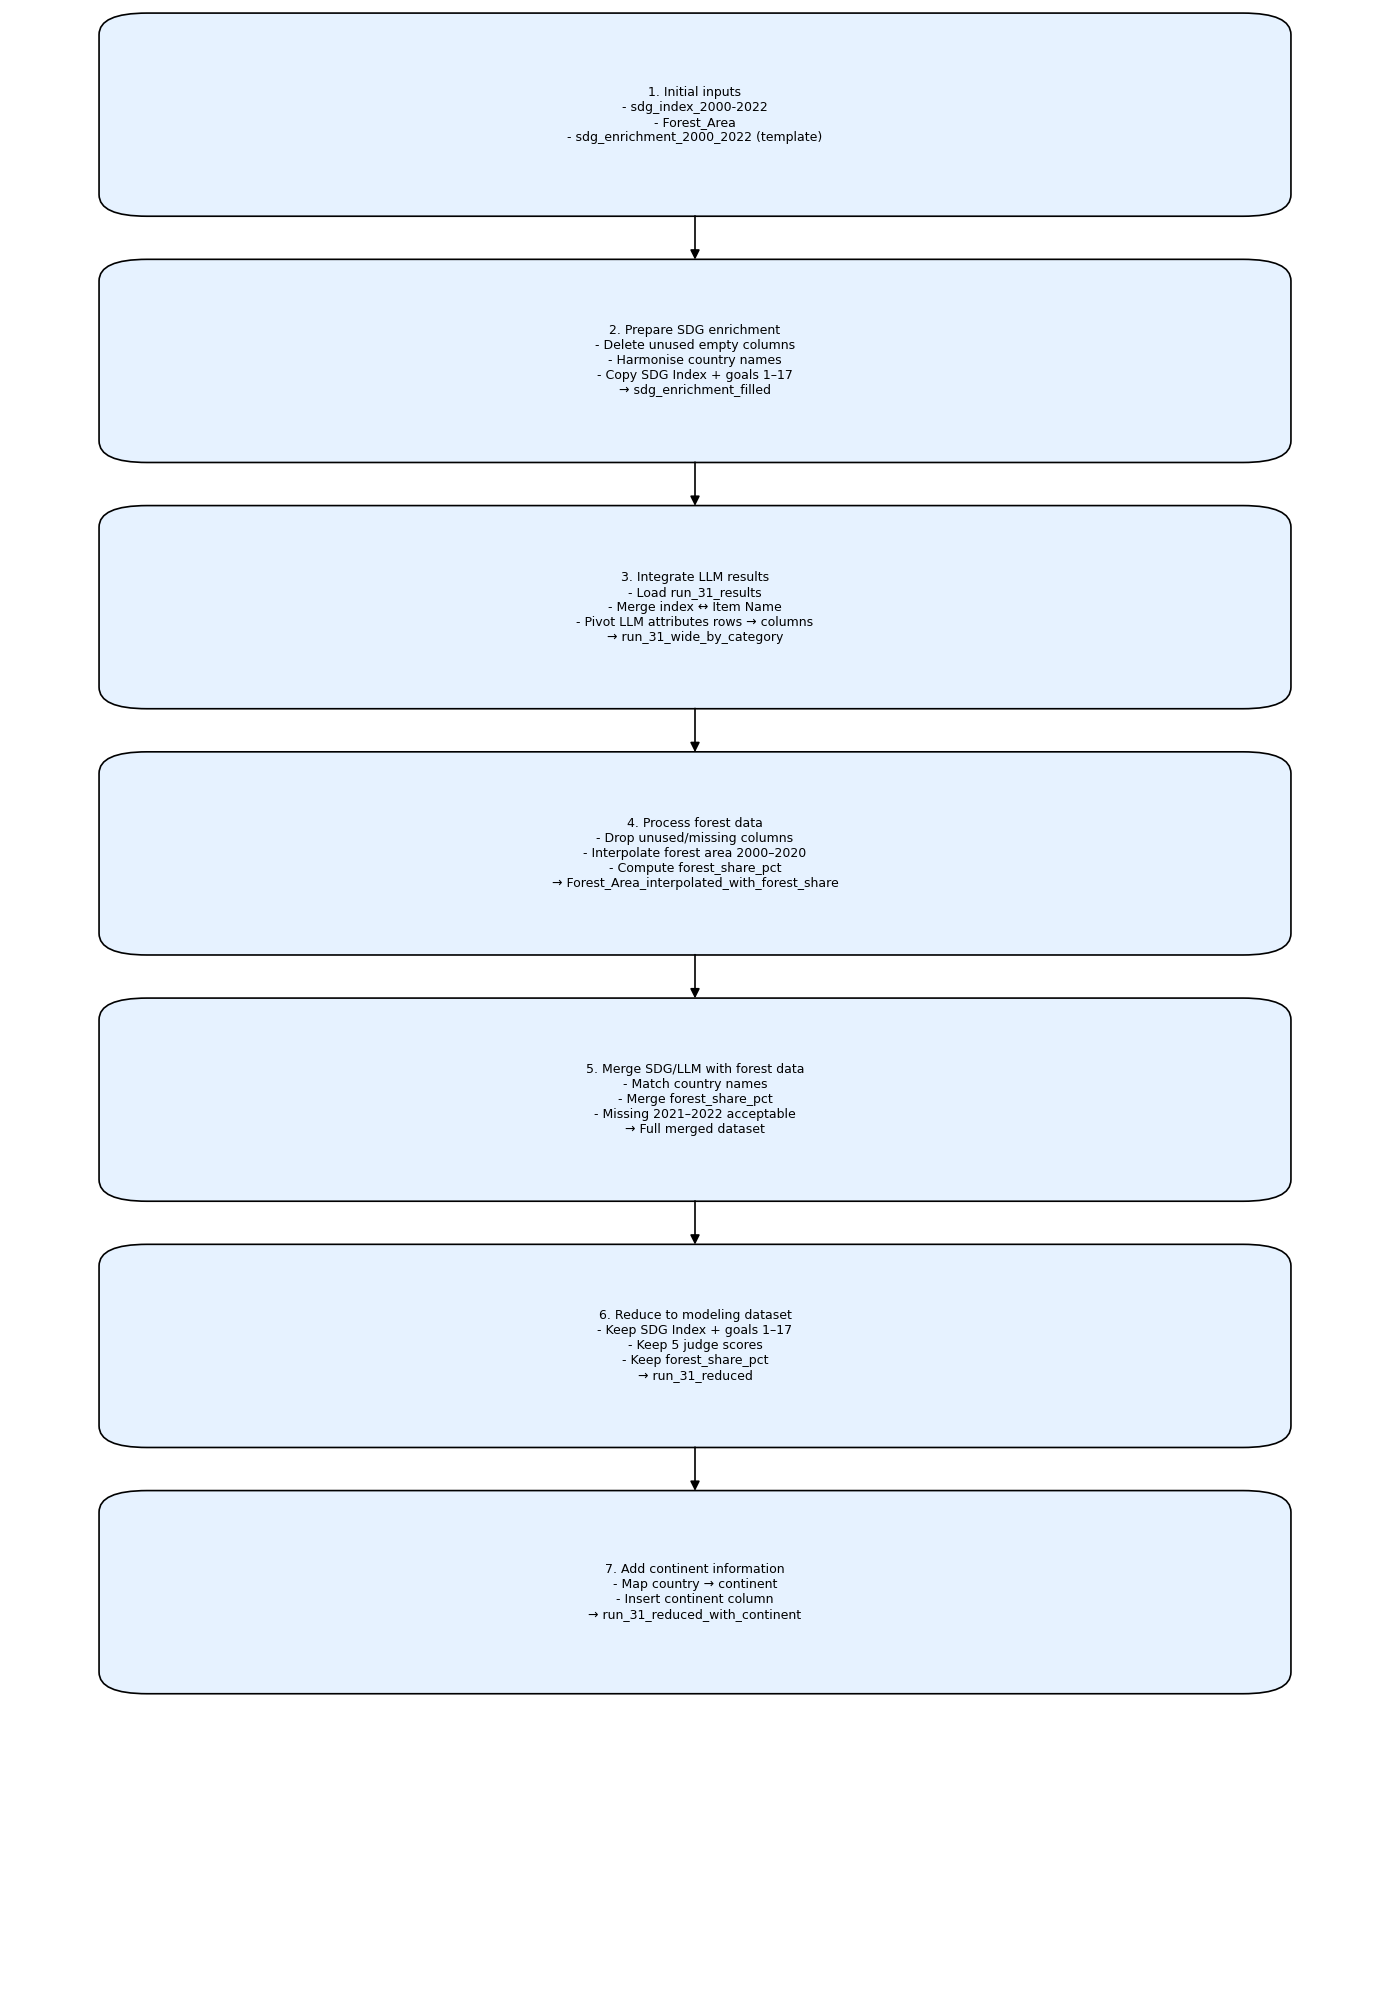

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.figure(figsize=(14, 20))      # even taller figure
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 32)                # more vertical space
ax.axis("off")

def box(name, x, y, text):
    rect = FancyBboxPatch(
        (x, y),
        8, 2.6,                   # slightly taller boxes for more text
        boxstyle="round,pad=0.35",
        linewidth=1.2,
        edgecolor="black",
        facecolor="#e6f2ff"
    )
    ax.add_patch(rect)
    ax.text(
        x + 4,
        y + 1.3,
        text,
        ha="center",
        va="center",
        fontsize=9,
        wrap=True,
    )
    centers[name] = (x + 4, y + 1.3)

def arrow(src, dst):
    (x1, y1) = centers[src]
    (x2, y2) = centers[dst]
    arr = FancyArrowPatch(
        (x1, y1 - 1.6),
        (x2, y2 + 1.6),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2,
        color="black",
    )
    ax.add_patch(arr)

centers = {}

# =============== BOXES WITH MORE VERTICAL SPACE ===============

box(
    "step1", 1, 29,
    "1. Initial inputs\n"
    "- sdg_index_2000-2022\n"
    "- Forest_Area\n"
    "- sdg_enrichment_2000_2022 (template)"
)

box(
    "step2", 1, 25,
    "2. Prepare SDG enrichment\n"
    "- Delete unused empty columns\n"
    "- Harmonise country names\n"
    "- Copy SDG Index + goals 1–17\n"
    "→ sdg_enrichment_filled"
)

box(
    "step3", 1, 21,
    "3. Integrate LLM results\n"
    "- Load run_31_results\n"
    "- Merge index ↔ Item Name\n"
    "- Pivot LLM attributes rows → columns\n"
    "→ run_31_wide_by_category"
)

box(
    "step4", 1, 17,
    "4. Process forest data\n"
    "- Drop unused/missing columns\n"
    "- Interpolate forest area 2000–2020\n"
    "- Compute forest_share_pct\n"
    "→ Forest_Area_interpolated_with_forest_share"
)

box(
    "step5", 1, 13,
    "5. Merge SDG/LLM with forest data\n"
    "- Match country names\n"
    "- Merge forest_share_pct\n"
    "- Missing 2021–2022 acceptable\n"
    "→ Full merged dataset"
)

box(
    "step6", 1, 9,
    "6. Reduce to modeling dataset\n"
    "- Keep SDG Index + goals 1–17\n"
    "- Keep 5 judge scores\n"
    "- Keep forest_share_pct\n"
    "→ run_31_reduced"
)

box(
    "step7", 1, 5,
    "7. Add continent information\n"
    "- Map country → continent\n"
    "- Insert continent column\n"
    "→ run_31_reduced_with_continent"
)

# =============== ARROWS ===============

arrow("step1", "step2")
arrow("step2", "step3")
arrow("step3", "step4")
arrow("step4", "step5")
arrow("step5", "step6")
arrow("step6", "step7")

plt.tight_layout()
plt.show()


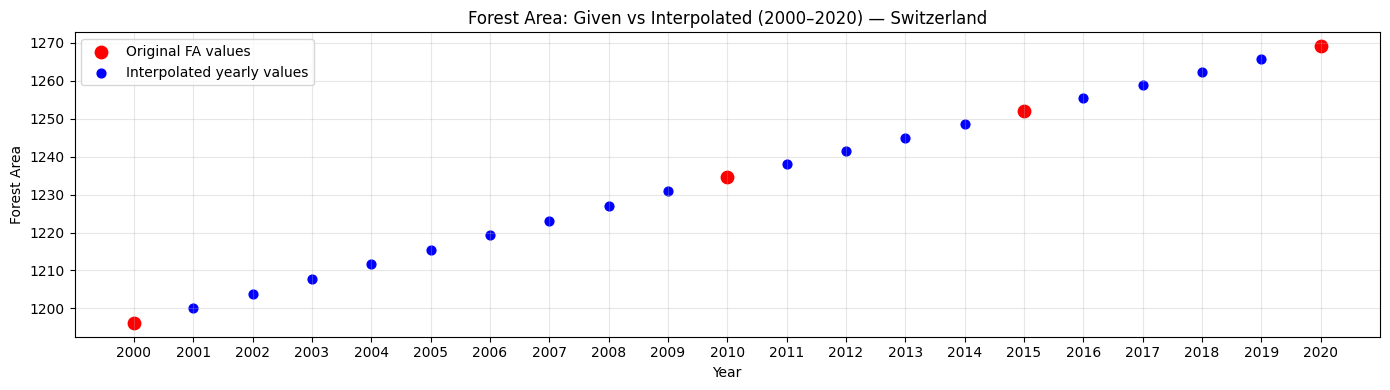

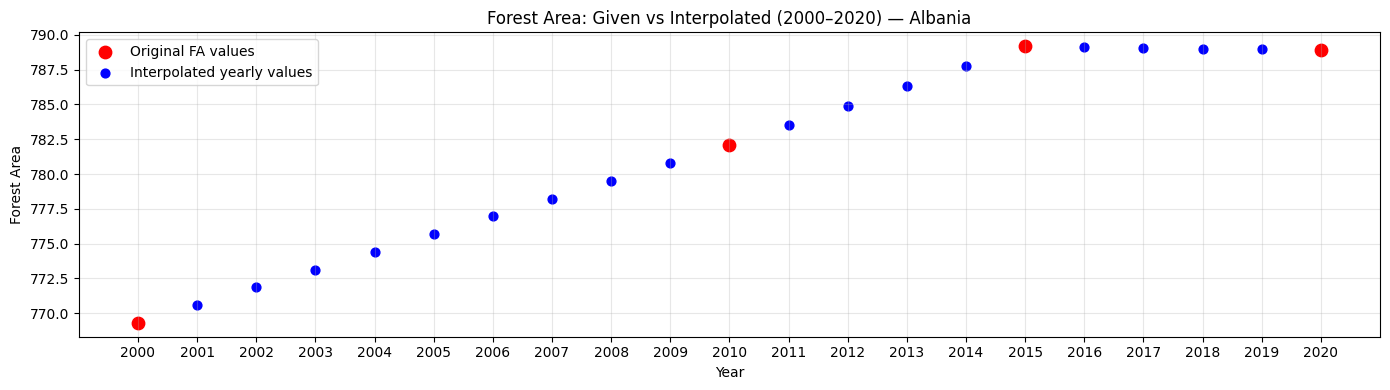

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
raw = pd.read_csv("Forest_Area_cleaned.csv", na_values=["..."])
interp = pd.read_csv("Forest_Area_interpolated_2000_2020.csv")

example = ["Switzerland", "Albania"]

# Sparse raw data years
raw_years_dict = {
    "Forest Area, 2000": 2000,
    "Forest Area, 2010": 2010,
    "Forest Area, 2015": 2015,
    "Forest Area, 2020": 2020,
}

for country in example:
    raw_country = raw[raw["Country and Area"] == country]

    # === RAW DATA ===
    raw_years = list(raw_years_dict.values())
    raw_values = [
        pd.to_numeric(raw_country[col], errors="coerce").values[0]
        for col in raw_years_dict
    ]

    # === INTERPOLATED DATA (filter out fractional years) ===
    interp_country = (
        interp[interp["Country and Area"] == country]
        .copy()
    )

    # Keep only integer years
    interp_country = interp_country[interp_country["year"] == interp_country["year"].astype(int)]
    interp_country["year"] = interp_country["year"].astype(int)

    # Remove interpolated values at raw years (to avoid overlap)
    interp_country = interp_country[~interp_country["year"].isin(raw_years)]

    # === Plot ===
    plt.figure(figsize=(14, 4))

    # Raw data (big red points)
    plt.scatter(raw_years, raw_values, color="red", s=80, label="Original FA values")

    # Interpolated full-year values (blue points)
    plt.scatter(
        interp_country["year"],
        interp_country["forest_area"],
        color="blue",
        s=40,
        label="Interpolated yearly values"
    )

    plt.title(f"Forest Area: Given vs Interpolated (2000–2020) — {country}")
    plt.xlabel("Year")
    plt.ylabel("Forest Area")
    plt.xticks(range(2000, 2021))   # ensure full years only
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Matching countries BEFORE harmonisation: 148
Matching countries AFTER harmonisation: 165


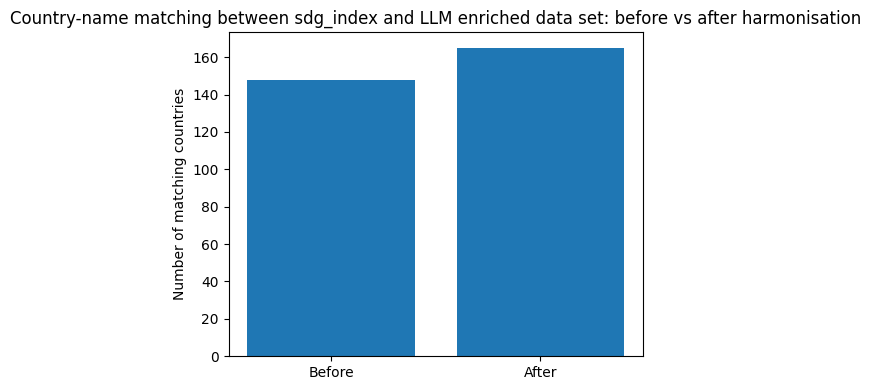

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- load before and extract country from name_year ---
enr_before = pd.read_csv("sdg_enrichment_cleaned.csv")
sdg = pd.read_csv("sdg_index_2000-2022.csv")

# sdg has a proper country column
sdg["country"] = sdg["country"].astype(str).str.strip()

# enrichment-before: extract country from "name_year", e.g. "Uganda 2000"
tmp = enr_before["name_year"].str.extract(r"^(.*)\s+(\d{4})$")
enr_before["country"] = tmp[0].astype(str).str.strip()

before_countries = set(enr_before["country"].dropna().unique())
sdg_countries    = set(sdg["country"].dropna().unique())

before_count = len(before_countries & sdg_countries)

# --- load after harmonisation (already has country column) ---
enr_after = pd.read_csv("sdg_enrichment_filled_correct.csv")
enr_after["country"] = enr_after["country"].astype(str).str.strip()

after_countries = set(enr_after["country"].dropna().unique())
after_count = len(after_countries & sdg_countries)

print("Matching countries BEFORE harmonisation:", before_count)
print("Matching countries AFTER harmonisation:", after_count)

# --- bar plot ---
plt.figure(figsize=(5,4))
plt.bar(["Before", "After"], [before_count, after_count])
plt.ylabel("Number of matching countries")
plt.title("Country-name matching between sdg_index and LLM enriched data set: before vs after harmonisation"
          )
plt.tight_layout()
plt.show()



## Visualizations to appropriately and clearly present the data modeling results, with a brief description of significant insights

**Modeling goals for our different tasks**

1. SDG time-trend regression plot

We chose three examples and plotted the SDG Index and selected goals (Goal 1, Goal 17) to show long-term global development patterns and compare them with example countries (Switzerland, United States, India, Brazil, Ethiopia).

2. Regression scatterplot (SDG vs. one LLM indicator) with fit line

We chose three examples and regressed those specific SDGs on selected LLM-generated societal attributes: Goal 5 (gender equality) on religiosity, Goal 16 (institutational strength) on political stability, and Goal 10 (more equality) on ethnic fractionalization. These variables were chosen because we thought there might be correlation/ potential causation.

3. KMeans clustering + PCA plot

We clustered countries using all SDG goal scores and the SDG Index (2000–2022 averages) to reveal overall development groupings. PCA was used to visualize these clusters.

4. Outlier- and pattern-highlighting plot (SDG–attribute relations)

we chose on SGD-attribute relation (Goal 16 vs. political stability) across continents in one year and marked outliers and looked for patterns. 

**Significant insights**

1. Time-trend plots show clear global progress in the SDG Index and selected goals, but substantial cross-country disparities persist.

2. The simple bivariate regressions yield weak associations: very low R² in two models and 0.34 for Goal 16, likely driven by endogeneity because political stability is part of institutional strength. These regressions rely on a single predictor and ignore standard econometric requirements. future work must extend them.

3. Clustering reveals three stable development groups, separated in PCA space: 

Cluster 0 (low-income Africa/South Asia)

Cluster 1 (high-income Europe/NA/Oceania)

Cluster 2 (emerging Latin America/Middle East and North Africa/Eastern Europe/Asia)

4. Some outliers which might  hint at wrong values for political stability. Pattern of different correlation of the two attributes across continents. 

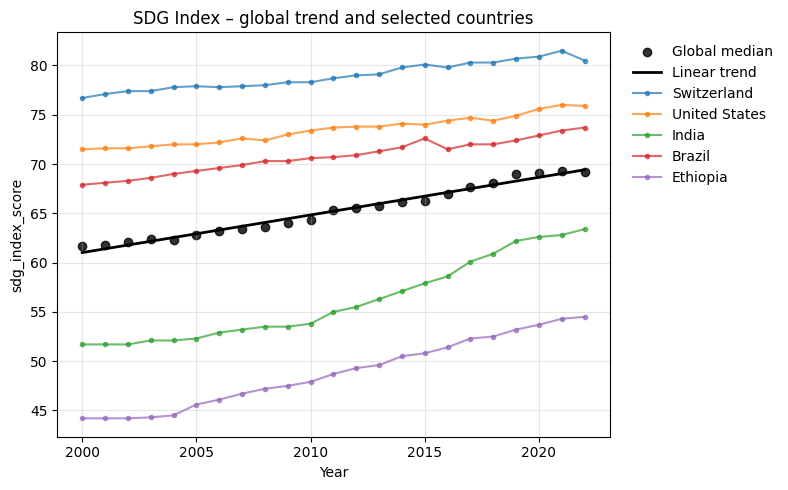

=== sdg_index_score ===
Estimated slope (points per year): 0.38176877470355725
Estimated intercept: -702.5196146245057



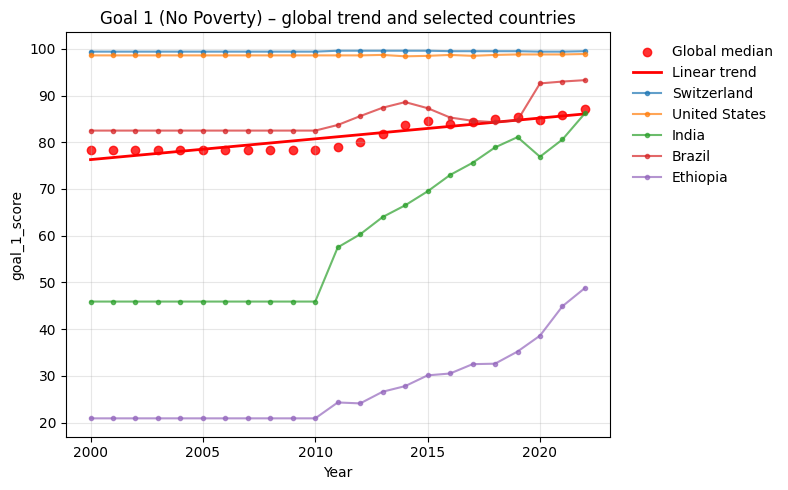

=== goal_1_score ===
Estimated slope (points per year): 0.4447628458498025
Estimated intercept: -813.2376482213442



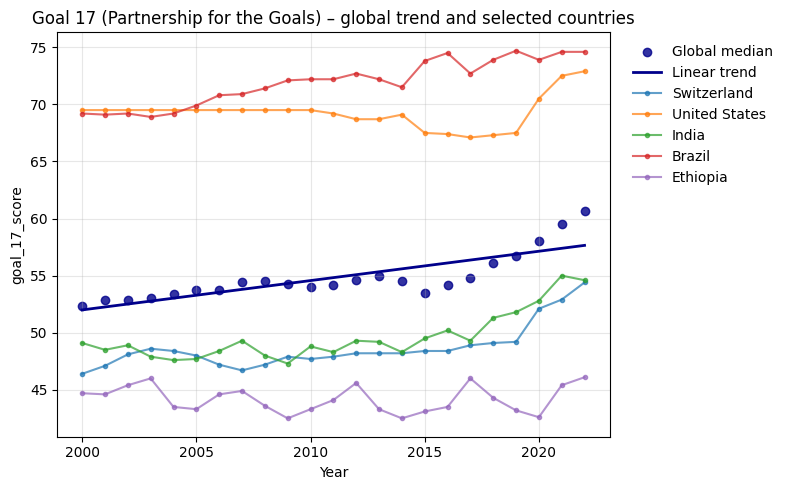

=== goal_17_score ===
Estimated slope (points per year): 0.25686758893280653
Estimated intercept: -461.7368083003957



In [ ]:
import pandas as pd
# Make sure year is numeric/int

df = pd.read_csv("run_31_reduced_with_continent.csv") 

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# Choose a few example countries to highlight (change as you like)
example_countries = [
    "Switzerland",
    "United States",
    "India",
    "Brazil",
    "Ethiopia",
]

def plot_time_trend_with_examples(df, score_col, title=None, examples=None, median_color="black"):
    """Plot global median over time + linear regression + some example countries."""
    tmp = df[["country", "year", score_col]].dropna().copy()
    tmp["year"] = tmp["year"].astype(int)

    # 1) Global median per year
    trend = (
        tmp.groupby("year")[score_col]
        .median()
        .reset_index()
        .sort_values("year")
    )

    X = trend[["year"]].to_numpy()
    y = trend[score_col].to_numpy()

    # Fit linear regression on the median trend
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    y_pred = lin_reg.predict(X)

    plt.figure(figsize=(8, 5))

    # Median points
    plt.scatter(
        trend["year"],
        trend[score_col],
        label="Global median",
        alpha=0.8,
        color=median_color,
    )

    # Regression line
    plt.plot(
        trend["year"],
        y_pred,
        label="Linear trend",
        linewidth=2,
        color=median_color,
    )

    # Example countries for illustration
    if examples is not None:
        for c in examples:
            sub = tmp[tmp["country"] == c].sort_values("year")
            if sub.empty:
                continue
            plt.plot(
                sub["year"],
                sub[score_col],
                marker="o",
                linewidth=1.5,
                markersize=3,
                alpha=0.7,
                label=c,
            )

    plt.xlabel("Year")
    plt.ylabel(score_col)
    plt.title(title or f"{score_col} – global trend and example countries")
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    print(f"=== {score_col} ===")
    print("Estimated slope (points per year):", lin_reg.coef_[0])
    print("Estimated intercept:", lin_reg.intercept_)
    print()


# --- SDG Index unchanged (default black) ---
plot_time_trend_with_examples(
    df,
    score_col="sdg_index_score",
    title="SDG Index – global trend and selected countries",
    examples=example_countries,
    median_color="black",
)

# --- Goal 1 in RED ---
plot_time_trend_with_examples(
    df,
    score_col="goal_1_score",
    title="Goal 1 (No Poverty) – global trend and selected countries",
    examples=example_countries,
    median_color="red",
)

# --- Goal 17 in DARK BLUE ---
plot_time_trend_with_examples(
    df,
    score_col="goal_17_score",
    title="Goal 17 (Partnership for the Goals) – global trend and selected countries",
    examples=example_countries,
    median_color="darkblue",
)


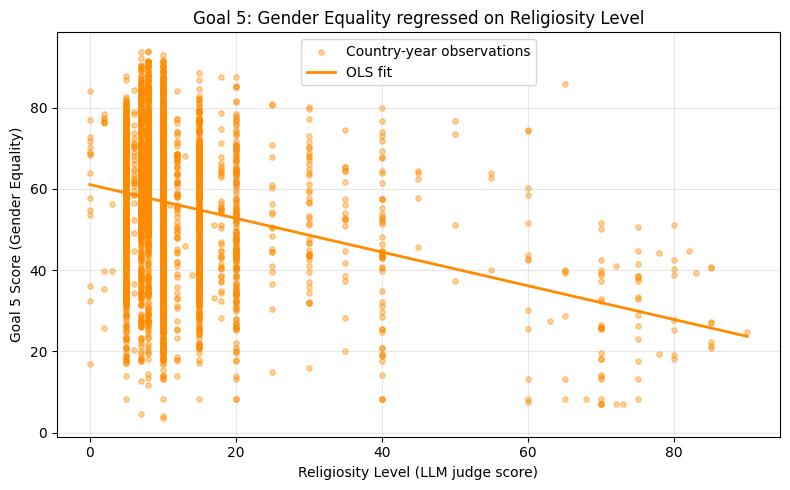

=== Regression results for Goal 5: Gender Equality regressed on Religiosity Level ===
Slope: -0.41536273428779
Intercept: 61.05493305538985
R²: 0.06405319556433253



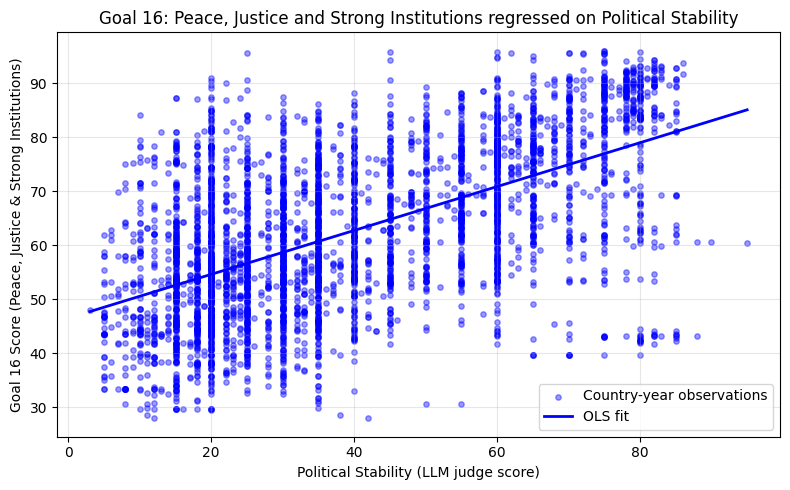

=== Regression results for Goal 16: Peace, Justice and Strong Institutions regressed on Political Stability ===
Slope: 0.40629312656945094
Intercept: 46.453567618258475
R²: 0.3420275872063959



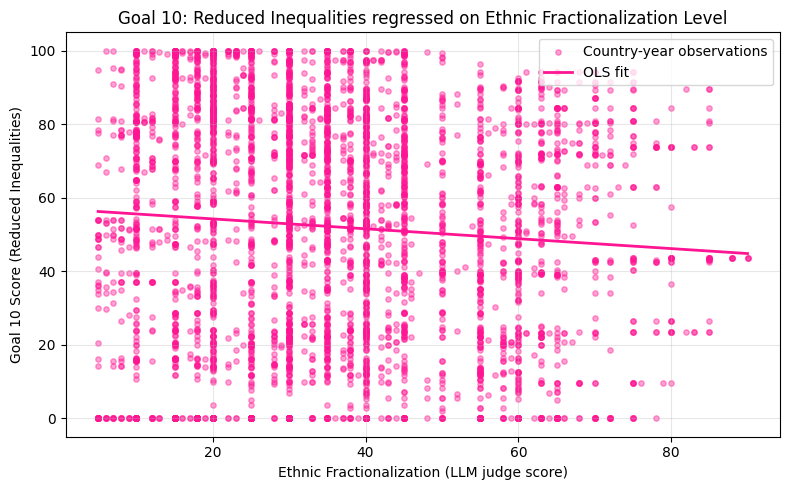

=== Regression results for Goal 10: Reduced Inequalities regressed on Ethnic Fractionalization Level ===
Slope: -0.13458275584260482
Intercept: 56.942543708488465
R²: 0.005727590500784863



In [11]:
# Load and ensure numeric
df = pd.read_csv("run_31_reduced.csv")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

def regression_plot(df, x_col, y_col, title, xlabel, ylabel, color="black"):
    """Scatter + OLS fit + printed coefficients."""
    data = df[[x_col, y_col]].dropna()

    X = data[[x_col]].to_numpy()
    y = data[y_col].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_grid = model.predict(x_grid)

    plt.figure(figsize=(8,5))
    
    # Scatter
    plt.scatter(
        data[x_col],
        data[y_col],
        alpha=0.4,
        s=15,
        label="Country-year observations",
        color=color
    )
    
    # Regression line
    plt.plot(
        x_grid,
        y_grid,
        linewidth=2,
        label="OLS fit",
        color=color
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"=== Regression results for {title} ===")
    print("Slope:", model.coef_[0])
    print("Intercept:", model.intercept_)
    print("R²:", model.score(X, y))
    print()


# ---------------------------------------------------------
# 1) Goal 5 (Gender Equality) on Religiosity — ORANGE
# ---------------------------------------------------------

regression_plot(
    df,
    x_col="religiosity_level_judge_score",
    y_col="goal_5_score",
    title="Goal 5: Gender Equality regressed on Religiosity Level",
    xlabel="Religiosity Level (LLM judge score)",
    ylabel="Goal 5 Score (Gender Equality)",
    color="darkorange"
)

# ---------------------------------------------------------------------
# 2) Goal 16 (Peace, Justice & Strong Institutions) on Political Stability — BLUE
# ---------------------------------------------------------------------

regression_plot(
    df,
    x_col="political_stability_judge_score",
    y_col="goal_16_score",
    title="Goal 16: Peace, Justice and Strong Institutions regressed on Political Stability",
    xlabel="Political Stability (LLM judge score)",
    ylabel="Goal 16 Score (Peace, Justice & Strong Institutions)",
    color="blue"
)

# --------------------------------------------------------------
# 3) Goal 10 (Reduced Inequalities) on Ethnic Fractionalization — PINK
# --------------------------------------------------------------

regression_plot(
    df,
    x_col="ethnic_fractionalization_level_judge_score",
    y_col="goal_10_score",
    title="Goal 10: Reduced Inequalities regressed on Ethnic Fractionalization Level",
    xlabel="Ethnic Fractionalization (LLM judge score)",
    ylabel="Goal 10 Score (Reduced Inequalities)",
    color="deeppink"
)


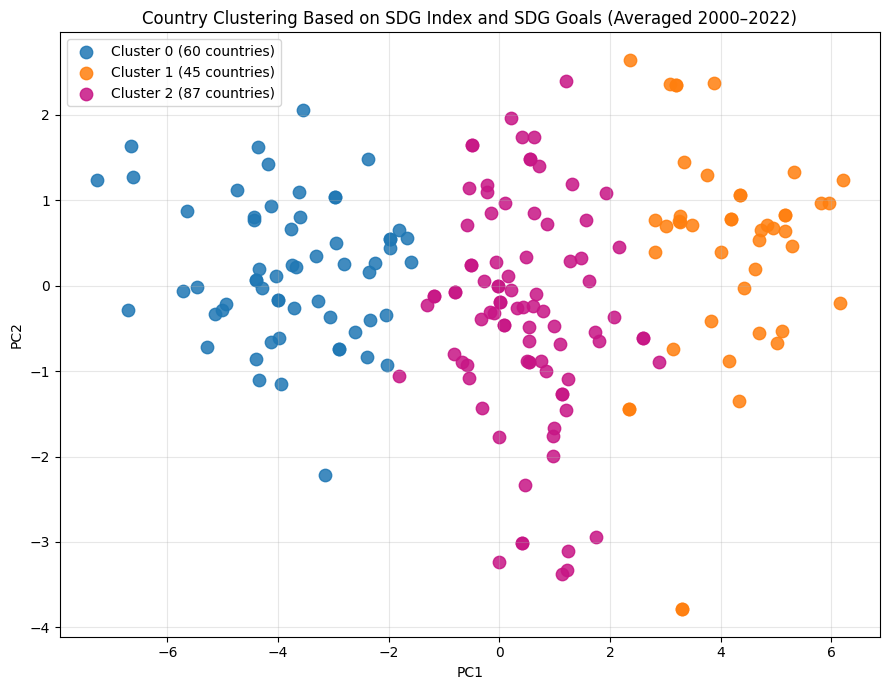

=== Countries per cluster ===

Cluster 0:
['Afghanistan', 'Andorra', 'Angola', 'Bangladesh', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Djibouti', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Haiti', 'India', 'Iraq', 'Kenya', 'Kiribati', 'Lao PDR', 'Lesotho', 'Liberia', 'Libya', 'Liechtenstein', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Myanmar', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Papua New Guinea', 'Rwanda', 'Saint Kitts and Nevis', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Somalia', 'South Sudan', 'Sudan', 'Syrian Arab Republic', 'Tanzania', 'Togo', 'Tuvalu', 'Uganda', 'Yemen, Rep.', 'Zambia', 'Zimbabwe']

Cluster 1:
['Australia', 'Austria', 'Belarus', 'Belgium', 'Canada', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Equatorial Guinea', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Icel

In [5]:
# Load data

df = pd.read_csv("run_31_reduced.csv")

# Identify all SDG columns
sdg_cols = ["sdg_index_score"] + [f"goal_{i}_score" for i in range(1, 17)]

# 1. Collapse SDG scores to country averages
country_sdg = (
    df[["country"] + sdg_cols]
    .dropna()
    .groupby("country")
    .mean()
    .reset_index()
)

X = country_sdg[sdg_cols].to_numpy()

# 2. Standardize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3. KMeans clustering (choose k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
country_sdg["cluster"] = kmeans.fit_predict(X_scaled)

# 4. PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

country_sdg["PC1"] = X_pca[:, 0]
country_sdg["PC2"] = X_pca[:, 1]

# 5. Plot clustering

cluster_colors = {
    0: "#1f77b4",   # blue
    1: "#ff7f0e",   # orange
    2: "#C71585",   # dark pink
}

plt.figure(figsize=(9,7))

for c in sorted(country_sdg["cluster"].unique()):
    sub = country_sdg[country_sdg["cluster"] == c]
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=80,
        alpha=0.85,
        color=cluster_colors[c],
        label=f"Cluster {c} ({len(sub)} countries)"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Clustering Based on SDG Index and SDG Goals (Averaged 2000–2022)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 6. Print country lists and mean SDG scores per cluster
print("=== Countries per cluster ===")
for c in sorted(country_sdg["cluster"].unique()):
    print(f"\nCluster {c}:")
    print(country_sdg[country_sdg["cluster"] == c]["country"].tolist())

print("\n=== Mean SDG performance per cluster ===")
print(
    country_sdg.groupby("cluster")[sdg_cols]
    .mean()
    .round(2)
)


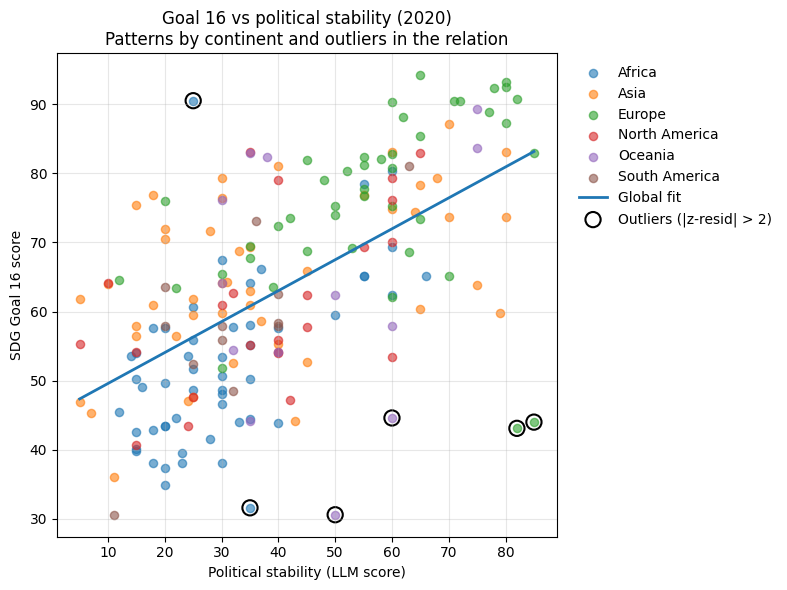


Correlation of Goal 16 vs political stability by region:
continent
South America    0.753307
Africa           0.570649
North America    0.534650
Asia             0.490161
Europe           0.360274
Oceania          0.190559


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- settings ---
PATH = "run_31_reduced_with_continent.csv"
year_ref = 2020                 # choose reference year for cross-section
REGION_COL = "continent"        # change to your actual column name, e.g. "region"

# --- load and subset ---
df = pd.read_csv(PATH)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

vars_needed = ["goal_16_score", "political_stability_judge_score", REGION_COL]
sub = df[df["year"] == year_ref].copy()
sub = sub.dropna(subset=vars_needed)

# --- global regression for Goal 16 ~ political stability ---
x = sub["political_stability_judge_score"].to_numpy(dtype=float)
y = sub["goal_16_score"].to_numpy(dtype=float)
b1, b0 = np.polyfit(x, y, 1)          # y = b1*x + b0

sub["pred"] = b1 * x + b0
sub["resid"] = y - sub["pred"]

# z-score of residuals to flag outliers in the *relationship*
sd = sub["resid"].std(ddof=1)
sub["z_resid"] = sub["resid"] / sd if sd and not np.isnan(sd) else 0
outliers = sub[sub["z_resid"].abs() > 2]   # |z| > 2 as outliers

# --- plot: pattern (by continent) + outliers ---
fig, ax = plt.subplots(figsize=(8, 6))

# 1) scatter coloured by region/continent
for reg, g in sub.groupby(REGION_COL):
    ax.scatter(
        g["political_stability_judge_score"],
        g["goal_16_score"],
        alpha=0.6,
        s=35,
        label=str(reg)
    )

# 2) global regression line
xx = np.linspace(x.min(), x.max(), 200)
ax.plot(xx, b1*xx + b0, linewidth=2, label="Global fit")

# 3) highlight outliers with a halo
if not outliers.empty:
    ax.scatter(
        outliers["political_stability_judge_score"],
        outliers["goal_16_score"],
        facecolors="none",
        edgecolors="black",
        s=120,
        linewidths=1.5,
        label="Outliers (|z-resid| > 2)"
    )

ax.set_title(f"Goal 16 vs political stability ({year_ref})\nPatterns by {REGION_COL} and outliers in the relation")
ax.set_xlabel("Political stability (LLM score)")
ax.set_ylabel("SDG Goal 16 score")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

# Optional: print correlation by region to describe patterns in text
corr_by_region = (
    sub.groupby(REGION_COL)[["goal_16_score", "political_stability_judge_score"]]
      .corr()
      .unstack()
      .iloc[:, 1]   # correlation between the two variables
      .rename("corr_goal16_stability")
      .sort_values(ascending=False)
)

print("\nCorrelation of Goal 16 vs political stability by region:")
print(corr_by_region.to_string())


## Short reflection on how well data wrangling and modeling decisions support our tasks and what we could refine to support them better 

Our data wrangling process successfully produced a coherent country–year dataset, allowing us to execute all planned analyses: time trends, regressions, clustering, and outlier detection. Harmonising country names, interpolating forest data, and restructuring LLM outputs into wide format worked well. There are still important limitations. though. The LLM-generated indicators show numerous abrupt jumps, indicating validity concerns. The regressions rely on single predictors and ignore key econometric assumptions, limiting interpretability. Our clustering used only one specification (K=3, averaged SDG scores), which limits interpretability and robustness. Our SDG-attribute outlier and pattern analysis used only one pair and a single outlier rule, but showed interesting continental differences in correlation. 

Further improvments:

- better validation of LLM scores
- multivariate regressions
- alternative K values, different feature subsets, and time-sensitive clustering
- evaluate SDG-attribute across all goals and attributes, do more country grouping (not just continent but e.g. income based) 

# Code



## Complete code for Dataset merging and preparation

In [3]:
#imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



In [ ]:
#remove the non necessary empty lines from sdg_enrichment (dataset we gave to LLM enrichment expert)
cleaned_lines = []

with open("sdg_enrichment_2000_2022 (2).csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Header stays 
cleaned_lines.append(lines[0].rstrip("\n"))

# Process all data rows
for line in lines[1:]:
    parts = line.rstrip("\n").split(",")

    # Remove last 5 empty elements (only if they are "")
    removed = 0
    while removed < 5 and parts and parts[-1] == "":
        parts.pop()
        removed += 1

    cleaned_lines.append(",".join(parts))

# Save 
with open("sdg_enrichment_cleaned.csv", "w", encoding="utf-8") as f:
    for l in cleaned_lines:
        f.write(l + "\n")


In [ ]:
#add missing sdg scores values for some countries from sdg_index to sdg enrichment file (noticed while checking sdg_enrichment)

# 1. Load files
enr = pd.read_csv("sdg_enrichment_cleaned.csv")
sdg = pd.read_csv("sdg_index_2000-2022.csv")

# 2. Extract country and year from name_year in enrichment
#    e.g. "Uganda 2000" -> country="Uganda", year=2000
tmp = enr["name_year"].str.extract(r"^(.*)\s+(\d{4})$")
enr["country"] = tmp[0]
enr["year"] = pd.to_numeric(tmp[1], errors="coerce")

# 3. Harmonise country names for merge (only where needed)
#    Enrichment uses "Venezuela", "Yemen"
#    SDG index uses "Venezuela, RB", "Yemen, Rep."
country_map = {
    "Venezuela": "Venezuela, RB",
    "Yemen": "Yemen, Rep.",
}
enr["country_merge"] = enr["country"].replace(country_map)

# 4. Prepare SDG index for merge
sdg["year"] = pd.to_numeric(sdg["year"], errors="coerce")

sdg_cols = ["sdg_index_score"] + [f"goal_{i}_score" for i in range(1, 18)]
sdg_sub = sdg[["country", "year"] + sdg_cols].copy()

# 5. Merge: use harmonised country names
enr_merged = enr.merge(
    sdg_sub,
    left_on=["country_merge", "year"],
    right_on=["country", "year"],
    how="left",
    suffixes=("", "_from_sdg")
)

# 6. Fill missing sdg_index_score and goal_1_score–goal_17_score
for col in sdg_cols:
    src = col + "_from_sdg"
    mask = enr_merged[col].isna() & enr_merged[src].notna()
    enr_merged.loc[mask, col] = enr_merged.loc[mask, src]

# 7. Clean up helper columns
cols_to_drop = [c for c in enr_merged.columns if c.endswith("_from_sdg")]
cols_to_drop += ["country_merge", "country_y"] if "country_y" in enr_merged.columns else ["country_merge"]
# if suffixes created 'country_from_sdg', this line already catches it

enr_merged = enr_merged.drop(columns=cols_to_drop, errors="ignore")

# 8. Save final file
enr_merged.to_csv("sdg_enrichment_filled.csv", index=False)


In [ ]:
# Load datasets
enr = pd.read_csv("sdg_enrichment_filled.csv")
sdg = pd.read_csv("sdg_index_2000-2022.csv")

# Clean country names
enr["country"] = enr["country"].astype(str).str.strip()
sdg["country"] = sdg["country"].astype(str).str.strip()

# Unique country lists
countries_enr = set(enr["country"].unique())
countries_sdg = set(sdg["country"].unique())

# Differences
only_in_enr = sorted(countries_enr - countries_sdg)
only_in_sdg = sorted(countries_sdg - countries_enr)

print("Countries only in sdg_enrichment:")
print(only_in_enr)

print("\nCountries only in sdg_index_2000-2022:")
print(only_in_sdg)


Countries only in sdg_enrichment:
['Andorra', 'Antigua and Barbuda', 'Bahamas', 'Brunei', 'Congo (Congo-Brazzaville)', 'Czech Republic', 'Democratic Republic of the Congo', 'Dominica', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Gambia', 'Grenada', 'Guinea-Bissau', 'Iran', 'Kiribati', 'Kyrgyzstan', 'Laos', 'Libya', 'Liechtenstein', 'Marshall Islands', 'Micronesia', 'Monaco', 'Nauru', 'North Korea', 'Palau', 'Russia', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa', 'San Marino', 'Seychelles', 'Slovakia', 'Solomon Islands', 'South Korea', 'Syria', 'Taiwan', 'Timor-Leste', 'Tonga', 'Turkey', 'Tuvalu', 'Vanuatu', 'Vatican City', 'Venezuela', 'Yemen']

Countries only in sdg_index_2000-2022:
['Bahamas, The', 'Brunei Darussalam', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Czechia', 'East and South Asia', 'Eastern Europe and Central Asia', 'Egypt, Arab Rep.', 'Gambia, The', 'High-income Countries', 'Iran, Islamic Rep.', 'Korea, Rep.', 'Kyrgyz Republ

In [ ]:
# overwrite sdg values from sdg enrichment_filled with the values from sdg_index; the sdg enrichment filled values are wrong, noticed when scores for a country were very high in a distribution table. We overwrite wthrm 

# paths

enr_path = "sdg_enrichment_filled.csv"   # enrichment file
sdg_path = "sdg_index_2000-2022.csv"               # SDG index file
out_path = "sdg_enrichment_filled_correct.csv"  # output


# data

enr = pd.read_csv(enr_path)
sdg = pd.read_csv(sdg_path)

# Basic cleaning
enr["country"] = enr["country"].astype(str).str.strip()
sdg["country"] = sdg["country"].astype(str).str.strip()

enr["year"] = enr["year"].astype(int)
sdg["year"] = sdg["year"].astype(int)


# match country names

country_rename = {
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo (Congo-Brazzaville)": "Congo, Rep.",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Czech Republic": "Czechia",
    "Egypt": "Egypt, Arab Rep.",
    "Gambia": "Gambia, The",
    "Iran": "Iran, Islamic Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Laos": "Lao PDR",
    "Russia": "Russian Federation",
    "Slovakia": "Slovak Republic",
    "South Korea": "Korea, Rep.",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, RB",
    "Yemen": "Yemen, Rep."
}

# Apply mapping only to enrichment so it matches SDG index naming
enr["country"] = enr["country"].replace(country_rename)


# check remaining country mismatches (optional but useful) ---

countries_enr = set(enr["country"].unique())
countries_sdg = set(sdg["country"].unique())

only_in_enr = sorted(countries_enr - countries_sdg)
only_in_sdg = sorted(countries_sdg - countries_enr)

print("Countries only in sdg_enrichment AFTER harmonisation:")
print(only_in_enr)
print("\nCountries only in sdg_index_2000-2022 AFTER harmonisation:")
print(only_in_sdg)


# columns to overwrite

overwrite_cols = [
    "sdg_index_score",
    "goal_1_score",
    "goal_2_score",
    "goal_3_score",
    "goal_4_score",
    "goal_5_score",
    "goal_6_score",
    "goal_7_score",
    "goal_8_score",
    "goal_9_score",
    "goal_10_score",
    "goal_11_score",
    "goal_12_score",
    "goal_13_score",
    "goal_14_score",
    "goal_15_score",
    "goal_16_score",
    "goal_17_score",
]

print("\nColumns that will be overwritten in enrichment:")
print(overwrite_cols)

# Quick check for missing columns
missing_in_enr = [c for c in overwrite_cols if c not in enr.columns]
missing_in_sdg = [c for c in overwrite_cols if c not in sdg.columns]

if missing_in_enr:
    print("\nWARNING: missing in enrichment:", missing_in_enr)
if missing_in_sdg:
    print("WARNING: missing in sdg_index:", missing_in_sdg)


# SDG scores table (country+year index)

sdg_scores = (
    sdg[["country", "year"] + overwrite_cols]
    .set_index(["country", "year"])
)

# Overwrite selected columns in enrichment with SDG index values

enr = enr.set_index(["country", "year"])
enr.update(sdg_scores)   # only affects columns that exist in enr
enr = enr.reset_index()


# Save updated enrichment dataset

enr.to_csv(out_path, index=False)
print(f"\nUpdated enrichment file written to: {out_path}")


Countries only in sdg_enrichment AFTER harmonisation:
['Andorra', 'Antigua and Barbuda', 'Dominica', 'Equatorial Guinea', 'Eritrea', 'Grenada', 'Guinea-Bissau', 'Kiribati', 'Libya', 'Liechtenstein', 'Marshall Islands', 'Micronesia', 'Monaco', 'Nauru', 'North Korea', 'Palau', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa', 'San Marino', 'Seychelles', 'Solomon Islands', 'Taiwan', 'Timor-Leste', 'Tonga', 'Tuvalu', 'Vanuatu', 'Vatican City']

Countries only in sdg_index_2000-2022 AFTER harmonisation:
["Cote d'Ivoire", 'East and South Asia', 'Eastern Europe and Central Asia', 'High-income Countries', 'Latin America and the Caribbean', 'Low-income Countries', 'Lower & Lower-middle Income', 'Lower-middle-income Countries', 'Middle East and North Africa', 'OECD members', 'Oceania', 'Small Island Developing States', 'Sub-Saharan Africa', 'Upper-middle-income Countries', 'World']

Columns that will be overwritten in enrichment:
['sdg_index_score', 'goal_1_sco

In [ ]:
#add sdg scores and country name to LLM-enriched data by using "index" and "item name" (identical) to merge them


# load files
enr = pd.read_csv("sdg_enrichment_filled_correct.csv")
run = pd.read_csv("run_31_results (1).csv")

# check if join keys are of the same type (int)
enr["index"] = pd.to_numeric(enr["index"], errors="coerce").astype("Int64")
run["Item Name"] = pd.to_numeric(run["Item Name"], errors="coerce").astype("Int64")

# Merge: one-to-many (1 row in enr, 5 rows in run)
merged = run.merge(
    enr,
    left_on="Item Name",
    right_on="index",
    how="left",
    suffixes=("", "_sdg")
)

# Now each row of run_31 has the SDG info attached

# check how many rows per index
counts = merged.groupby("Item Name")["index"].nunique()
print("Unique index per Item Name (should all be 1):")
print(counts.value_counts())

rows_per_item = merged.groupby("Item Name").size()
print("Distribution of rows per Item Name (ideally 5):")
print(rows_per_item.value_counts().sort_index())

# Save result
merged.to_csv("run_31_with_sdg_enrichment.csv", index=False)



Unique index per Item Name (should all be 1):
index
1    4462
Name: count, dtype: int64
Distribution of rows per Item Name (ideally 5):
5    4462
Name: count, dtype: int64


In [ ]:
#check if we merged correctly

merged = pd.read_csv("run_31_with_sdg_enrichment.csv")

print("Unique index per Item Name:")
print(merged.groupby("Item Name")["index"].nunique().value_counts())

rows_per_item = merged.groupby("Item Name").size()
print("Rows per Item Name (how many items have 5 rows, 4 rows, etc.):")
print(rows_per_item.value_counts().sort_index())




Unique index per Item Name:
index
1    4462
Name: count, dtype: int64
Rows per Item Name (how many items have 5 rows, 4 rows, etc.):
5    4462
Name: count, dtype: int64


In [ ]:
#turning our LLM enriched categories into columns

# load merged file
df = pd.read_csv("run_31_with_sdg_enrichment.csv")

# Identifier columns (one row per item)
id_cols = [
    "Item ID",
    "Item Name",
    "index",
    "name_year",
    "country",
    "year",
    "sdg_index_score",
] + [f"goal_{i}_score" for i in range(1, 18)]

# Metrics to include for each category (all 9)
metric_cols = [
    "Judge Score",
    "Judge Confidence",
    "Average Score",
    "Average Confidence",
    "Score StdDev",
    "Confidence StdDev",
    "Judge Best Model",
    "Judge Ranking",
    "Judge Reasoning",
]

# Pivot
wide = df.pivot(
    index=id_cols,
    columns="Category Name",
    values=metric_cols
)

# to flatten column names (metric, category) → category_metric
wide.columns = [
    f"{category}_{metric}".lower().replace(" ", "_")
    for metric, category in wide.columns
]

# restore normal columns
wide = wide.reset_index()

# save dataset
wide.to_csv("run_31_wide_by_category.csv", index=False)


In [ ]:
#see if we changed rows to columns correctly

df_long = pd.read_csv("run_31_with_sdg_enrichment.csv")
df_wide = pd.read_csv("run_31_wide_by_category.csv")

id_cols = [
    "Item ID",
    "Item Name",
    "index",
    "name_year",
    "country",
    "year",
]

n_long = df_long[id_cols].drop_duplicates().shape[0]
n_wide = df_wide.shape[0]

print("Unique items in long:", n_long)
print("Rows in wide:", n_wide)

judge_cols = [c for c in df_wide.columns if c.endswith("_judge_score")]
df_wide[judge_cols].notna().sum(axis=1).value_counts()



Unique items in long: 4462
Rows in wide: 4462


5    4462
Name: count, dtype: int64

In [ ]:
df = pd.read_csv("run_31_wide_by_category.csv")

# Identify key columns for display
key_cols = ["index", "name_year", "country", "year"]

# For every row, find columns that are NaN
missing_info = []

for idx, row in df.iterrows():
    missing_cols = row[row.isna()].index.tolist()
    
    if missing_cols:  # only keep rows with missing values
        missing_info.append({
            "index": row["index"],
            "name_year": row["name_year"],
            "country": row["country"],
            "year": row["year"],
            "missing_columns": missing_cols
        })

missing_df = pd.DataFrame(missing_info)

# Show  rows
missing_df

#looks acceptable; only three values for judge best model missing (unimportant column). Then no sdg values for Vanuatu und and Vatican City. They are not in our original sdg_index_2000-2022 dataset. We delete these two rows

,index,name_year,country,year,missing_columns
0,913,Costa Rica 2015,Costa Rica,2015,[political_stability_judge_best_model]
1,1520,Grenada 2001,Grenada,2001,[ethnic_fractionalization_level_judge_best_model]
2,3829,Switzerland 2010,Switzerland,2010,[ethnic_fractionalization_level_judge_best_model]
3,4302,Vanuatu 2000,Vanuatu,2000,"[sdg_index_score, goal_1_score, goal_2_score, ..."
4,4303,Vanuatu 2001,Vanuatu,2001,"[sdg_index_score, goal_1_score, goal_2_score, ..."
5,4304,Vanuatu 2002,Vanuatu,2002,"[sdg_index_score, goal_1_score, goal_2_score, ..."
6,4305,Vanuatu 2003,Vanuatu,2003,"[sdg_index_score, goal_1_score, goal_2_score, ..."
7,4306,Vanuatu 2004,Vanuatu,2004,"[sdg_index_score, goal_1_score, goal_2_score, ..."
8,4307,Vanuatu 2005,Vanuatu,2005,"[sdg_index_score, goal_1_score, goal_2_score, ..."
9,4308,Vanuatu 2006,Vanuatu,2006,"[sdg_index_score, goal_1_score, goal_2_score, ..."


In [ ]:
#let's delete them and check for missing values again

df = pd.read_csv("run_31_wide_by_category.csv")

# Remove Vanuatu and Vatican City
df_clean = df[~df["country"].isin(["Vanuatu", "Vatican City"])]

# Save result
df_clean.to_csv("run_31_wide_no_vanuatu_vatican.csv", index=False)




In [ ]:
df = pd.read_csv("run_31_wide_no_vanuatu_vatican.csv")

# Identify key columns for display
key_cols = ["index", "name_year", "country", "year"]

# For every row, find columns that are NaN
missing_info = []

for idx, row in df.iterrows():
    missing_cols = row[row.isna()].index.tolist()
    
    if missing_cols:  # only keep rows with missing values
        missing_info.append({
            "index": row["index"],
            "name_year": row["name_year"],
            "country": row["country"],
            "year": row["year"],
            "missing_columns": missing_cols
        })

missing_df = pd.DataFrame(missing_info)

# Show  rows
missing_df

#looks good

,index,name_year,country,year,missing_columns
0,913,Costa Rica 2015,Costa Rica,2015,[political_stability_judge_best_model]
1,1520,Grenada 2001,Grenada,2001,[ethnic_fractionalization_level_judge_best_model]
2,3829,Switzerland 2010,Switzerland,2010,[ethnic_fractionalization_level_judge_best_model]


In [ ]:
#look at Forest_Area dataset before merging with big dataset, checking for missing values

# data, treating "..." as missing
df = pd.read_csv("Forest_Area.csv", na_values=["..."])

# Keep only rows with a country name
df = df[df["Country and Area"].notna()]

# Columns we care about for missingness
value_cols = [
    "Forest Area, 1990",
    "Forest Area, 2000",
    "Forest Area, 2010",
    "Forest Area, 2015",
    "Forest Area, 2020",
    "Total Land Area, 2020",
    "Forest Area as a Proportion of Total Land Area, 2020",
    "Deforestation, 2015-2020",
    "Total Forest Area Affected by Fire, 2015",
]

# Collect missing columns per country
missing_info = []

for _, row in df.iterrows():
    missing_cols = [col for col in value_cols if pd.isna(row[col])]
    if missing_cols:
        missing_info.append({
            "Country": row["Country and Area"],
            "Missing Columns": ", ".join(missing_cols)
        })

missing_df = pd.DataFrame(missing_info)

# Inspect result
print(missing_df)

# some values are missing, but they are nearly only in the two columns Deforestation, 2015-2020" and"Total Forest Area Affected by Fire, 2015 and we do not use this two for G2. We delete them. 



                                Country  \
0                           Afghanistan   
1                               Albania   
2                               Algeria   
3                        American Samoa   
4                               Andorra   
..                                  ...   
148  Venezuela (Bolivarian Republic of)   
149                            Viet Nam   
150           Wallis and Futuna Islands   
151                      Western Sahara   
152                               Yemen   

                                       Missing Columns  
0    Deforestation, 2015-2020, Total Forest Area Af...  
1    Deforestation, 2015-2020, Total Forest Area Af...  
2             Total Forest Area Affected by Fire, 2015  
3                             Deforestation, 2015-2020  
4    Deforestation, 2015-2020, Total Forest Area Af...  
..                                                 ...  
148           Total Forest Area Affected by Fire, 2015  
149           Total Forest 

In [ ]:
# Load the dataset, treating "..." as missing
df = pd.read_csv("Forest_Area.csv", na_values=["..."])

# Columns to drop
cols_to_drop = [
    "Deforestation, 2015-2020",
    "Total Forest Area Affected by Fire, 2015"
]

# Drop them
df_clean = df.drop(columns=cols_to_drop)

# Save cleaned dataset
df_clean.to_csv("Forest_Area_cleaned.csv", index=False)


In [ ]:
#linearly interpolate the values of forest area for the years we do not have it

# Load cleaned forest area data
df = pd.read_csv("Forest_Area_cleaned.csv", na_values=["..."])

# Keep only needed columns
base = df[[
    "CountryID", "Country and Area",
    "Forest Area, 2000", "Forest Area, 2010",
    "Forest Area, 2015", "Forest Area, 2020"
]].copy()

# Convert to numeric
for col in [
    "Forest Area, 2000", "Forest Area, 2010",
    "Forest Area, 2015", "Forest Area, 2020"
]:
    base[col] = pd.to_numeric(base[col], errors="coerce")

# convert to long
long = base.melt(
    id_vars=["CountryID", "Country and Area"],
    var_name="year",
    value_name="forest_area"
)

# Extract numeric year
long["year"] = long["year"].str.extract(r"(\d{4})").astype(int)

# 
# Create full grid of all countries × all years
years = pd.DataFrame({"year": range(2000, 2021)})

countries = base[["CountryID", "Country and Area"]].drop_duplicates()
countries["key"] = 1
years["key"] = 1
full_grid = countries.merge(years, on="key").drop(columns="key")

# Merge known values onto the full grid
panel = full_grid.merge(long, on=["CountryID", "Country and Area", "year"], how="left")
# our fix is until here

# Ensure forest_area is numeric
panel["forest_area"] = pd.to_numeric(panel["forest_area"], errors="coerce")

#linear interpolation
panel["forest_area"] = (
    panel.groupby(["CountryID", "Country and Area"])["forest_area"]
         .transform(lambda x: x.interpolate())
)

# Fill edges
panel["forest_area"] = (
    panel.groupby(["CountryID", "Country and Area"])["forest_area"]
         .transform(lambda x: x.ffill().bfill())
)

# Sort for readability
panel = panel.sort_values(["Country and Area", "year"])

# Save
panel.to_csv("Forest_Area_interpolated_2000_2020.csv", index=False)


In [ ]:
#we compute forest share by diving our forest area values by total land are in 2020

# Load interpolated forest area
interpolated = pd.read_csv("Forest_Area_interpolated_2000_2020.csv")

# Load cleaned forest dataset (with land area)
clean = pd.read_csv("Forest_Area_cleaned.csv", na_values=["..."])

land = clean[["CountryID", "Country and Area", "Total Land Area, 2020"]].copy()

merged = interpolated.merge(
    land,
    on=["CountryID", "Country and Area"],
    how="left"
)
merged["forest_share"] = (
    merged["forest_area"] / merged["Total Land Area, 2020"]
)
merged["forest_share_pct"] = merged["forest_share"] * 100
merged.to_csv("Forest_Area_interpolated_with_forest_share.csv", index=False)



In [2]:
import pandas as pd

#we add forest share to our full dataset, since we want to merge by country we check which countries are only in one dataset

# Load both datasets
main = pd.read_csv("run_31_wide_no_vanuatu_vatican.csv")
forest = pd.read_csv("Forest_Area_interpolated_with_forest_share.csv")

# Ensure country fields are strings (VERY IMPORTANT)
main["country"] = main["country"].astype(str)
forest["Country and Area"] = forest["Country and Area"].astype(str)

# Extract unique country sets
main_countries = set(main["country"].unique())
forest_countries = set(forest["Country and Area"].unique())

# Compute mismatches safely (no TypeError possible)
only_in_main = sorted(list(main_countries - forest_countries))
only_in_forest = sorted(list(forest_countries - main_countries))

print("Countries only in main dataset:\n", only_in_main)
print("\nCountries only in forest dataset:\n", only_in_forest)

#now we need to map the different names correctly and we ignore the countries that are only in the forest dataset

import pandas as pd

# load datasets
main = pd.read_csv("run_31_wide_no_vanuatu_vatican.csv")
forest = pd.read_csv("Forest_Area_interpolated_with_forest_share.csv")

# ensure country columns are strings
main["country"] = main["country"].astype(str)
forest["Country and Area"] = forest["Country and Area"].astype(str)

# country name mapping (main -> forest)
country_map = {
    "Bahamas, The": "Bahamas",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Egypt, Arab Rep.": "Egypt",
    "Gambia, The": "Gambia",
    "Iran, Islamic Rep.": "Iran (Islamic Republic of)",
    "Korea, Rep.": "Republic of Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Lao People's Democratic Republic",
    "Micronesia": "Micronesia (Federated States of)",
    "Moldova": "Republic of Moldova",
    "North Korea": "Democratic People's Republic of Korea",
    "Slovak Republic": "Slovakia",
    "Tanzania": "United Republic of Tanzania",
    "Türkiye": "Turkey",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "United States": "United States of America",
    "Venezuela, RB": "Venezuela (Bolivarian Republic of)",
    "Vietnam": "Viet Nam",
    "Yemen, Rep.": "Yemen",
    # No match in forest dataset for Taiwan – will stay missing
}

# apply mapping to main for merge
main["country_for_merge"] = main["country"].replace(country_map)

# merge forest_share_pct onto main (left join to not lose any rows)
merged = main.merge(
    forest[["Country and Area", "year", "forest_share_pct"]],
    left_on=["country_for_merge", "year"],
    right_on=["Country and Area", "year"],
    how="left"
)

# clean up helper columns
merged = merged.drop(columns=["Country and Area", "country_for_merge"])

# round forest_share_pct
merged["forest_share_pct"] = merged["forest_share_pct"].round(2)

# Save final dataset
merged.to_csv("run_31_wide_with_forest_share.csv", index=False)





Countries only in main dataset:
 ['Bahamas, The', 'Bolivia', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Egypt, Arab Rep.', 'Gambia, The', 'Iran, Islamic Rep.', 'Korea, Rep.', 'Kyrgyz Republic', 'Lao PDR', 'Micronesia', 'Moldova', 'North Korea', 'Slovak Republic', 'Taiwan', 'Tanzania', 'Türkiye', 'United Kingdom', 'United States', 'Venezuela, RB', 'Vietnam', 'Yemen, Rep.']

Countries only in forest dataset:
 ['American Samoa', 'Anguilla', 'Aruba', 'Bahamas', 'Bermuda', 'Bolivia (Plurinational State of)', 'Bonaire, Sint Eustatius and Saba', 'British Virgin Islands', 'Cayman Islands', 'Congo', 'Cook Islands', 'Curaçao', 'Côte d\x92Ivoire', "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Egypt', 'Faeroe Islands', 'Falkland Islands (Malvinas)', 'French Guiana', 'French Polynesia', 'Gambia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam', 'Guernsey', 'Holy See', 'Iran (Islamic Republic of)', 'Isle of Man', 'Jersey', 'Kyrgyzstan', "Lao People's Democratic Republic", 'Ma

In [29]:
#check if we still have missing forest share for some countries

missing = merged[merged["forest_share_pct"].isna()]
print("Rows with missing forest_share_pct:", len(missing))
print(missing[["country", "year"]].drop_duplicates().head(30))

#we do, but this is ok, since our forest area dataset only goes up to year 2020


Rows with missing forest_share_pct: 426
                 country  year
21           Afghanistan  2021
22           Afghanistan  2022
44               Albania  2021
45               Albania  2022
67               Algeria  2021
68               Algeria  2022
90               Andorra  2021
91               Andorra  2022
113               Angola  2021
114               Angola  2022
136  Antigua and Barbuda  2021
137  Antigua and Barbuda  2022
159            Argentina  2021
160            Argentina  2022
182              Armenia  2021
183              Armenia  2022
205            Australia  2021
206            Australia  2022
228              Austria  2021
229              Austria  2022
251           Azerbaijan  2021
252           Azerbaijan  2022
274         Bahamas, The  2021
275         Bahamas, The  2022
297              Bahrain  2021
298              Bahrain  2022
320           Bangladesh  2021
321           Bangladesh  2022
343             Barbados  2021
344             Barbados  2022

In [ ]:

import pandas as pd
#create a compact dataset for simpler usage
# Load your full dataset (adjust filename if different)
df = pd.read_csv("run_31_wide_with_forest_share.csv")

# SDG columns
sdg_cols = ["sdg_index_score"] + [f"goal_{i}_score" for i in range(1, 18)]

# Judge score columns (exactly the ones you mentioned)
judge_cols = [
    "discrimination_level_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "political_stability_judge_score",
    "religiosity_level_judge_score",
]


# Columns we want to KEEP
keep_cols = (
    ["Item ID", "index", "country", "year"]  # identifiers
    + sdg_cols                               # SDG scores
    + judge_cols                             # LLM judge scores
    + ["forest_share_pct"]                   # forest share
)

# Create reduced dataframe by explicit selection
df_reduced = df[keep_cols].copy()

# Save to new file
df_reduced.to_csv("run_31_reduced.csv", index=False)

# add continent 


df = pd.read_csv("run_31_reduced.csv")  # your dataset

continent_map = {

    # Africa
    "Algeria": "Africa", "Angola": "Africa", "Benin": "Africa", "Botswana": "Africa",
    "Burkina Faso": "Africa", "Burundi": "Africa", "Cabo Verde": "Africa",
    "Cameroon": "Africa", "Central African Republic": "Africa", "Chad": "Africa",
    "Comoros": "Africa", "Congo, Dem. Rep.": "Africa", "Congo, Rep.": "Africa",
    "Djibouti": "Africa", "Egypt, Arab Rep.": "Africa", "Equatorial Guinea": "Africa",
    "Eritrea": "Africa", "Eswatini": "Africa", "Ethiopia": "Africa", "Gabon": "Africa",
    "Gambia, The": "Africa", "Ghana": "Africa", "Guinea": "Africa",
    "Guinea-Bissau": "Africa", "Kenya": "Africa", "Lesotho": "Africa",
    "Liberia": "Africa", "Libya": "Africa", "Madagascar": "Africa",
    "Malawi": "Africa", "Mali": "Africa", "Mauritania": "Africa",
    "Mauritius": "Africa", "Mozambique": "Africa", "Namibia": "Africa",
    "Niger": "Africa", "Nigeria": "Africa", "Rwanda": "Africa",
    "Sao Tome and Principe": "Africa", "Senegal": "Africa", "Seychelles": "Africa",
    "Sierra Leone": "Africa", "Somalia": "Africa", "South Africa": "Africa",
    "South Sudan": "Africa", "Sudan": "Africa", "Tanzania": "Africa",
    "Togo": "Africa", "Tunisia": "Africa", "Uganda": "Africa", "Zambia": "Africa",
    "Zimbabwe": "Africa", "Morocco": "Africa",

    # Asia
    "Afghanistan": "Asia", "Armenia": "Asia", "Azerbaijan": "Asia",
    "Bahrain": "Asia", "Bangladesh": "Asia", "Bhutan": "Asia", "Brunei Darussalam": "Asia",
    "Cambodia": "Asia", "China": "Asia", "Georgia": "Asia", "India": "Asia",
    "Indonesia": "Asia", "Iran, Islamic Rep.": "Asia", "Iraq": "Asia", "Israel": "Asia",
    "Japan": "Asia", "Jordan": "Asia", "Kazakhstan": "Asia", "Korea, Rep.": "Asia",
    "Kuwait": "Asia", "Kyrgyz Republic": "Asia", "Lao PDR": "Asia", "Lebanon": "Asia",
    "Malaysia": "Asia", "Maldives": "Asia", "Mongolia": "Asia", "Myanmar": "Asia",
    "Nepal": "Asia", "North Korea": "Asia", "Oman": "Asia", "Pakistan": "Asia",
    "Philippines": "Asia", "Qatar": "Asia", "Saudi Arabia": "Asia",
    "Singapore": "Asia", "Sri Lanka": "Asia", "Syrian Arab Republic": "Asia",
    "Taiwan": "Asia", "Tajikistan": "Asia", "Thailand": "Asia", "Timor-Leste": "Asia",
    "Turkmenistan": "Asia", "Türkiye": "Asia", "United Arab Emirates": "Asia",
    "Uzbekistan": "Asia", "Vietnam": "Asia", "Yemen, Rep.": "Asia",

    # Europe
    "Albania": "Europe", "Andorra": "Europe", "Austria": "Europe",
    "Belarus": "Europe", "Belgium": "Europe", "Bosnia and Herzegovina": "Europe",
    "Bulgaria": "Europe", "Croatia": "Europe", "Cyprus": "Europe", "Czechia": "Europe",
    "Denmark": "Europe", "Estonia": "Europe", "Finland": "Europe", "France": "Europe",
    "Germany": "Europe", "Greece": "Europe", "Hungary": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Italy": "Europe", "Latvia": "Europe", "Liechtenstein": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Malta": "Europe",
    "Moldova": "Europe", "Monaco": "Europe", "Montenegro": "Europe",
    "Netherlands": "Europe", "North Macedonia": "Europe", "Norway": "Europe",
    "Poland": "Europe", "Portugal": "Europe", "Romania": "Europe",
    "Russian Federation": "Europe", "San Marino": "Europe", "Serbia": "Europe",
    "Slovak Republic": "Europe", "Slovenia": "Europe", "Spain": "Europe",
    "Sweden": "Europe", "Switzerland": "Europe", "Ukraine": "Europe",
    "United Kingdom": "Europe",

    # North America
    "Antigua and Barbuda": "North America", "Bahamas, The": "North America",
    "Barbados": "North America", "Belize": "North America", "Canada": "North America",
    "Costa Rica": "North America", "Cuba": "North America", "Dominica": "North America",
    "Dominican Republic": "North America", "El Salvador": "North America",
    "Grenada": "North America", "Guatemala": "North America", "Haiti": "North America",
    "Honduras": "North America", "Jamaica": "North America", "Mexico": "North America",
    "Nicaragua": "North America", "Panama": "North America",
    "Saint Kitts and Nevis": "North America", "Saint Lucia": "North America",
    "Saint Vincent and the Grenadines": "North America",
    "Trinidad and Tobago": "North America", "United States": "North America",

    # South America
    "Argentina": "South America", "Bolivia": "South America", "Brazil": "South America",
    "Chile": "South America", "Colombia": "South America", "Ecuador": "South America",
    "Guyana": "South America", "Paraguay": "South America", "Peru": "South America",
    "Suriname": "South America", "Uruguay": "South America", "Venezuela, RB": "South America",

    # Oceania
    "Australia": "Oceania", "New Zealand": "Oceania", "Fiji": "Oceania",
    "Kiribati": "Oceania", "Marshall Islands": "Oceania",
    "Micronesia": "Oceania", "Nauru": "Oceania", "Palau": "Oceania",
    "Papua New Guinea": "Oceania", "Samoa": "Oceania", "Solomon Islands": "Oceania",
    "Tonga": "Oceania", "Tuvalu": "Oceania"
}

# ADD continent column (next to country)


df["continent"] = df["country"].map(continent_map)

# Move continent right after country
cols = df.columns.tolist()
cols.insert(1, cols.pop(cols.index("continent")))
df = df[cols]

# Check for any unmatched countries
missing = df[df["continent"].isna()]["country"].unique()
print("Missing mappings:", missing)

df.to_csv("run_31_reduced_with_continent.csv", index=False)
df.head()





Missing mappings: []


,Item ID,continent,index,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,...,goal_14_score,goal_15_score,goal_16_score,goal_17_score,discrimination_level_judge_score,ethnic_fractionalization_level_judge_score,media_freedom_score_judge_score,political_stability_judge_score,religiosity_level_judge_score,forest_share_pct
0,4579,Asia,1,Afghanistan,2000,36.0,28.8,27.3,19.2,1.6,...,0.0,51.9,39.2,34.2,90,12,5,5,20,1.85
1,4580,Asia,2,Afghanistan,2001,36.3,28.8,30.6,19.4,1.6,...,0.0,51.9,39.2,34.2,85,72,5,5,85,1.85
2,4581,Asia,3,Afghanistan,2002,36.3,28.8,30.7,19.7,1.6,...,0.0,51.8,39.2,34.2,78,63,13,12,10,1.85
3,4582,Asia,4,Afghanistan,2003,36.7,28.8,32.5,19.9,1.6,...,0.0,51.8,39.2,34.2,75,64,12,11,15,1.85
4,4583,Asia,5,Afghanistan,2004,37.1,28.8,32.1,21.1,1.6,...,0.0,51.8,39.2,34.2,70,65,7,17,40,1.85


## Code for distribution tables

In [ ]:
warnings.filterwarnings("ignore", category=FutureWarning)

PATH = "run_31_reduced.csv"

ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_17_score",
]

def load_cols(path, cols):
    usecols = ["country", "year"] + cols
    df = pd.read_csv(path, usecols=usecols)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def yearly_quantiles(df, col, qs=(0.10, 0.25, 0.50, 0.75, 0.90)):
    g = (
        df.dropna(subset=[col, "year"])
          .assign(year=lambda x: x["year"].astype(int))
          .groupby("year")[col]
          .quantile(qs)
          .unstack()
          .sort_index()
    )
    g.columns = [f"q{int(q*100)}" for q in qs]
    return g

def pick_representatives(
    df,
    col,
    n_low=2,
    n_high=2,
    n_up=1,
    n_down=1,
    min_values_per_country=3,
):
    g = df.dropna(subset=[col, "year"]).copy()
    if g.empty:
        return []

    g["year_i"] = g["year"].astype(int)

    # keep only countries with enough real values
    valid_counts = g.groupby("country")[col].count()
    keep_countries = valid_counts[valid_counts >= min_values_per_country].index
    g = g[g["country"].isin(keep_countries)]

    if g.empty:
        return []

    # level-based representatives (low vs high mean)
    mean_lvl = g.groupby("country")[col].mean().sort_values()
    lows  = list(mean_lvl.head(n_low).index)
    highs = list(mean_lvl.tail(n_high).index)

    # slope-based representatives (strongest up / down trends)
    def slope(gr):
        gg = gr.dropna(subset=[col, "year_i"]).sort_values("year_i")
        if gg["year_i"].nunique() < 2:
            return np.nan
        x = gg["year_i"].to_numpy()
        y = gg[col].to_numpy()
        return np.polyfit(x, y, 1)[0]

    sl = g.groupby("country").apply(slope).dropna()
    if sl.empty:
        reps = list(dict.fromkeys(lows + highs))
        return reps

    ups   = list(sl.sort_values(ascending=False).head(n_up).index)
    downs = list(sl.sort_values().head(n_down).index)

    reps = list(dict.fromkeys(lows + highs + ups + downs))
    return reps

def plot_ribbon_with_reps(df, col, reps, title=None):
    qtab = yearly_quantiles(df, col)
    fig, ax = plt.subplots(figsize=(11, 6))

    if not qtab.empty:
        years = qtab.index.values
        if "q10" in qtab and "q90" in qtab:
            ax.fill_between(years, qtab["q10"], qtab["q90"], alpha=0.12, label="P10–P90")
        if "q25" in qtab and "q75" in qtab:
            ax.fill_between(years, qtab["q25"], qtab["q75"], alpha=0.20, label="IQR (P25–P75)")
        if "q50" in qtab:
            ax.plot(years, qtab["q50"], linewidth=2.1, color="k", label="Median")

    g = (
        df.dropna(subset=[col, "year"])
          .assign(year_i=lambda x: x["year"].astype(int))
          .sort_values(["country", "year_i"])
    )

    # only plot reps that actually have values
    for c in reps:
        gi = g[g["country"] == c]
        if gi.empty or gi[col].isna().all():
            continue
        ax.plot(
            gi["year_i"],
            gi[col],
            linewidth=1.6,
            marker="o",
            markersize=3,
            label=c,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel(col)
    ax.set_title(title or f"{col} — distribution + representative countries")
    ax.grid(True, alpha=0.35)
    if reps:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Selected countries")
    plt.tight_layout()
    plt.show()

f = load_cols(PATH, ATTRS)

for col in ATTRS:
    reps = pick_representatives(f, col)
    # Do not print representatives in PDF
    plot_ribbon_with_reps(f, col, reps, title=col)



## Code for Year-by-Year distribution plots

In [ ]:
df = pd.read_csv("run_31_reduced.csv")

# All numeric attributes we want distributions for
DIST_ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_17_score",
]

df["year"] = df["year"].astype(int)

def plot_yearly_distribution(df, col):
    tmp = df[["year", col]].dropna()

    # Pivot: each column is one year
    pivot = tmp.pivot(columns="year", values=col)

    # Plot
    plt.figure(figsize=(16, 5))
    box = pivot.boxplot(
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", alpha=0.5),
        medianprops=dict(color="darkred", linewidth=2),
    )

    plt.title(f"{col} — yearly distribution", fontsize=14, pad=10)
    plt.ylabel(col)

    # Show only every 2nd year to avoid too many values
    ticks = plt.xticks()[0]
    labels = [int(l.get_text()) for l in plt.gca().get_xticklabels()]
    for i, label in enumerate(plt.gca().get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
        label.set_rotation(45)
        label.set_fontsize(8)

    plt.tight_layout()
    plt.show()

for col in DIST_ATTRS:
    plot_yearly_distribution(df, col)


## Code for attributes' data quality

In [ ]:
PATH = "run_31_reduced.csv"

ATTRS = [
    "political_stability_judge_score",
    "ethnic_fractionalization_level_judge_score",
    "media_freedom_score_judge_score",
    "forest_share_pct",
    "discrimination_level_judge_score",
    "religiosity_level_judge_score",
    "sdg_index_score",
    "goal_1_score",
    "goal_2_score",
    "goal_3_score",
    "goal_4_score",
    "goal_5_score",
    "goal_6_score",
    "goal_7_score",
    "goal_8_score",
    "goal_9_score",
    "goal_10_score",
    "goal_11_score",
    "goal_12_score",
    "goal_13_score",
    "goal_14_score",
    "goal_15_score",
    "goal_16_score",
    "goal_17_score",
]

# Validity bounds (default 0–100)
BOUNDS = {a: (0, 100) for a in ATTRS}
BOUNDS["forest_share_pct"] = (0, 100)

df = pd.read_csv(PATH)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# convert all ATTRS to numeric
for col in ATTRS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def iqr_outliers(series):
    """Return lower_fence, upper_fence, count_outliers using Q1-1.5IQR rule."""
    s = series.dropna()
    if len(s) < 5:
        return (np.nan, np.nan, 0)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = int(((s < low) | (s > high)).sum())
    return (low, high, n_out)

results = []

for col in ATTRS:
    s = df[col]
    lo, hi = BOUNDS[col]

    missing = int(s.isna().sum())
    missing_pct = round(100 * missing / len(s), 2)

    invalid_low  = int((s < lo).sum())
    invalid_high = int((s > hi).sum())

    low_fence, high_fence, n_out = iqr_outliers(s)

    # consistency: large jumps year-over-year (>40 points)
    jumps = 0
    if "year" in df.columns:
        for c, g in df[["country", "year", col]].dropna().groupby("country"):
            g = g.sort_values("year")
            delta = g[col].diff().abs()
            jumps += int((delta > 40).sum())

    # duplicates (conflicting country-year values)
    dups = df.groupby(["country", "year"])[col].nunique()
    inconsist = int((dups > 1).sum())

    results.append({
        "attribute": col,
        "missing": missing,
        "missing_%": missing_pct,
        "invalid_low": invalid_low,
        "invalid_high": invalid_high,
        "iqr_lower_fence": None if pd.isna(low_fence) else round(low_fence, 2),
        "iqr_upper_fence": None if pd.isna(high_fence) else round(high_fence, 2),
        "outliers_IQR_rule": n_out,
        "large_jumps": jumps,
        "duplicate_conflicts": inconsist
    })

dq = pd.DataFrame(results)
dq


##  Code for visualizations for data wrangling progress/ results 

In [ ]:
#Load datasets
raw = pd.read_csv("Forest_Area_cleaned.csv", na_values=["..."])
interp = pd.read_csv("Forest_Area_interpolated_2000_2020.csv")

# pick two representative countries (change if needed)
example = ["Switzerland", "Albania"]

# Raw columns
raw_cols = {
    "Forest Area, 2000": 2000,
    "Forest Area, 2010": 2010,
    "Forest Area, 2015": 2015,
    "Forest Area, 2020": 2020,
}

for country in example:
    raw_country = raw[raw["Country and Area"] == country]

    if raw_country.empty:
        print(f"No raw data for {country}")
        continue

    # raw sparse points
    raw_years = list(raw_cols.values())
    raw_values = [pd.to_numeric(raw_country[col], errors="coerce").values[0] for col in raw_cols]

    # interpolated annual series
    interp_country = interp[interp["Country and Area"] == country].sort_values("year")

    plt.figure(figsize=(8,4))
    # raw points
    plt.scatter(raw_years, raw_values, color="red", s=60, label="FA data ")
    # interpolated line
    plt.plot(interp_country["year"], interp_country["forest_area"], color="blue", label="Interpolated annual values")

    plt.title(f"Forest Area: Given vs Interpolated (2000–2020) — {country}")
    plt.xlabel("Year")
    plt.ylabel("Forest Area")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    import pandas as pd
import matplotlib.pyplot as plt

# load before and extract country from name_year
enr_before = pd.read_csv("sdg_enrichment_cleaned.csv")
sdg = pd.read_csv("sdg_index_2000-2022.csv")

# sdg has a proper country column
sdg["country"] = sdg["country"].astype(str).str.strip()

# enrichment-before: extract country from "name_year", e.g. "Uganda 2000"
tmp = enr_before["name_year"].str.extract(r"^(.*)\s+(\d{4})$")
enr_before["country"] = tmp[0].astype(str).str.strip()

before_countries = set(enr_before["country"].dropna().unique())
sdg_countries    = set(sdg["country"].dropna().unique())

before_count = len(before_countries & sdg_countries)

# load after harmonisation (already has country column)
enr_after = pd.read_csv("sdg_enrichment_filled_correct.csv")
enr_after["country"] = enr_after["country"].astype(str).str.strip()

after_countries = set(enr_after["country"].dropna().unique())
after_count = len(after_countries & sdg_countries)

print("Matching countries BEFORE harmonisation:", before_count)
print("Matching countries AFTER harmonisation:", after_count)

# bar plot
plt.figure(figsize=(5,4))
plt.bar(["Before", "After"], [before_count, after_count])
plt.ylabel("Number of matching countries")
plt.title("Country-name matching between sdg_index and LLM enriched data set: before vs after harmonisation"
          )
plt.tight_layout()
plt.show()




## Code for Flowchart

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.figure(figsize=(12, 14))
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis("off")

def box(name, x, y, text):
    rect = FancyBboxPatch(
        (x, y),
        8, 1.8,
        boxstyle="round,pad=0.35",
        linewidth=1.2,
        edgecolor="black",
        facecolor="#e6f2ff"
    )
    ax.add_patch(rect)
    ax.text(x + 4, y + 0.9, text, ha="center", va="center", fontsize=9)
    centers[name] = (x + 4, y + 0.9)

def arrow(src, dst):
    (x1, y1) = centers[src]
    (x2, y2) = centers[dst]
    arr = FancyArrowPatch(
        (x1, y1 - 0.95),
        (x2, y2 + 0.95),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2
    )
    ax.add_patch(arr)

centers = {}


box("step1", 1, 18,
    "1. Initial Inputs:\n"
    "- sdg_index_2000-2022\n"
    "- Forest_Area\n"
    "- sdg_enrichment_2000_2022 (template)"
)

box("step2", 1, 15,
    "2. Prepare SDG Enrichment:\n"
    "- delete empty cols\n"
    "- harmonise names\n"
    "- add SDG goals → filled"
)

box("step3", 1, 12,
    "3. Integrate LLM Results:\n"
    "- merge run_31_results\n"
    "- pivot LLM attributes → wide"
)

box("step4", 1, 9,
    "4. Process Forest Data:\n"
    "- drop unused cols\n"
    "- interpolate 2000–2020\n"
    "- compute forest_share_pct"
)

box("step5", 1, 6,
    "5. Merge Forest + SDG/LLM:\n"
    "- match names\n"
    "- merge forest_share_pct"
)

box("step6", 1, 3,
    "6. Reduce Dataset:\n"
    "- keep SDG Index + goals 1–17\n"
    "- keep judge scores\n"
    "- keep forest_share_pct"
)

box("step7", 1, 0,
    "7. Add Continent:\n"
    "- map country → continent\n"
    "- final dataset ready"
)

# -------------------------
# Connect arrows
# -------------------------
arrow("step1", "step2")
arrow("step2", "step3")
arrow("step3", "step4")
arrow("step4", "step5")
arrow("step5", "step6")
arrow("step6", "step7")

plt.show()


## Code for visualiation of data modeling results

In [ ]:
import pandas as pd
# Make sure year is numeric/int

df = pd.read_csv("run_31_reduced_with_continent.csv") 

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# Choose a few example countries to highlight (change as you like)
example_countries = [
    "Switzerland",
    "United States",
    "India",
    "Brazil",
    "Ethiopia",
]

def plot_time_trend_with_examples(df, score_col, title=None, examples=None, median_color="black"):
    """Plot global median over time + linear regression + some example countries."""
    tmp = df[["country", "year", score_col]].dropna().copy()
    tmp["year"] = tmp["year"].astype(int)

    # 1) Global median per year
    trend = (
        tmp.groupby("year")[score_col]
        .median()
        .reset_index()
        .sort_values("year")
    )

    X = trend[["year"]].to_numpy()
    y = trend[score_col].to_numpy()

    # Fit linear regression on the median trend
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    y_pred = lin_reg.predict(X)

    plt.figure(figsize=(8, 5))

    # Median points
    plt.scatter(
        trend["year"],
        trend[score_col],
        label="Global median",
        alpha=0.8,
        color=median_color,
    )

    # Regression line
    plt.plot(
        trend["year"],
        y_pred,
        label="Linear trend",
        linewidth=2,
        color=median_color,
    )

    # Example countries for illustration
    if examples is not None:
        for c in examples:
            sub = tmp[tmp["country"] == c].sort_values("year")
            if sub.empty:
                continue
            plt.plot(
                sub["year"],
                sub[score_col],
                marker="o",
                linewidth=1.5,
                markersize=3,
                alpha=0.7,
                label=c,
            )

    plt.xlabel("Year")
    plt.ylabel(score_col)
    plt.title(title or f"{score_col} – global trend and example countries")
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    print(f"=== {score_col} ===")
    print("Estimated slope (points per year):", lin_reg.coef_[0])
    print("Estimated intercept:", lin_reg.intercept_)
    print()


# --- SDG Index unchanged (default black) ---
plot_time_trend_with_examples(
    df,
    score_col="sdg_index_score",
    title="SDG Index – global trend and selected countries",
    examples=example_countries,
    median_color="black",
)

# --- Goal 1 in RED ---
plot_time_trend_with_examples(
    df,
    score_col="goal_1_score",
    title="Goal 1 (No Poverty) – global trend and selected countries",
    examples=example_countries,
    median_color="red",
)

# --- Goal 17 in DARK BLUE ---
plot_time_trend_with_examples(
    df,
    score_col="goal_17_score",
    title="Goal 17 (Partnership for the Goals) – global trend and selected countries",
    examples=example_countries,
    median_color="darkblue",
)


In [ ]:
# Load and ensure numeric
df = pd.read_csv("run_31_reduced.csv")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

def regression_plot(df, x_col, y_col, title, xlabel, ylabel, color="black"):
    """Scatter + OLS fit + printed coefficients."""
    data = df[[x_col, y_col]].dropna()

    X = data[[x_col]].to_numpy()
    y = data[y_col].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_grid = model.predict(x_grid)

    plt.figure(figsize=(8,5))
    
    # Scatter
    plt.scatter(
        data[x_col],
        data[y_col],
        alpha=0.4,
        s=15,
        label="Country-year observations",
        color=color
    )
    
    # Regression line
    plt.plot(
        x_grid,
        y_grid,
        linewidth=2,
        label="OLS fit",
        color=color
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"=== Regression results for {title} ===")
    print("Slope:", model.coef_[0])
    print("Intercept:", model.intercept_)
    print("R²:", model.score(X, y))
    print()


# ---------------------------------------------------------
# 1) Goal 5 (Gender Equality) on Religiosity — ORANGE
# ---------------------------------------------------------

regression_plot(
    df,
    x_col="religiosity_level_judge_score",
    y_col="goal_5_score",
    title="Goal 5: Gender Equality regressed on Religiosity Level",
    xlabel="Religiosity Level (LLM judge score)",
    ylabel="Goal 5 Score (Gender Equality)",
    color="darkorange"
)

# ---------------------------------------------------------------------
# 2) Goal 16 (Peace, Justice & Strong Institutions) on Political Stability — BLUE
# ---------------------------------------------------------------------

regression_plot(
    df,
    x_col="political_stability_judge_score",
    y_col="goal_16_score",
    title="Goal 16: Peace, Justice and Strong Institutions regressed on Political Stability",
    xlabel="Political Stability (LLM judge score)",
    ylabel="Goal 16 Score (Peace, Justice & Strong Institutions)",
    color="blue"
)

# --------------------------------------------------------------
# 3) Goal 10 (Reduced Inequalities) on Ethnic Fractionalization — PINK
# --------------------------------------------------------------

regression_plot(
    df,
    x_col="ethnic_fractionalization_level_judge_score",
    y_col="goal_10_score",
    title="Goal 10: Reduced Inequalities regressed on Ethnic Fractionalization Level",
    xlabel="Ethnic Fractionalization (LLM judge score)",
    ylabel="Goal 10 Score (Reduced Inequalities)",
    color="deeppink"
)


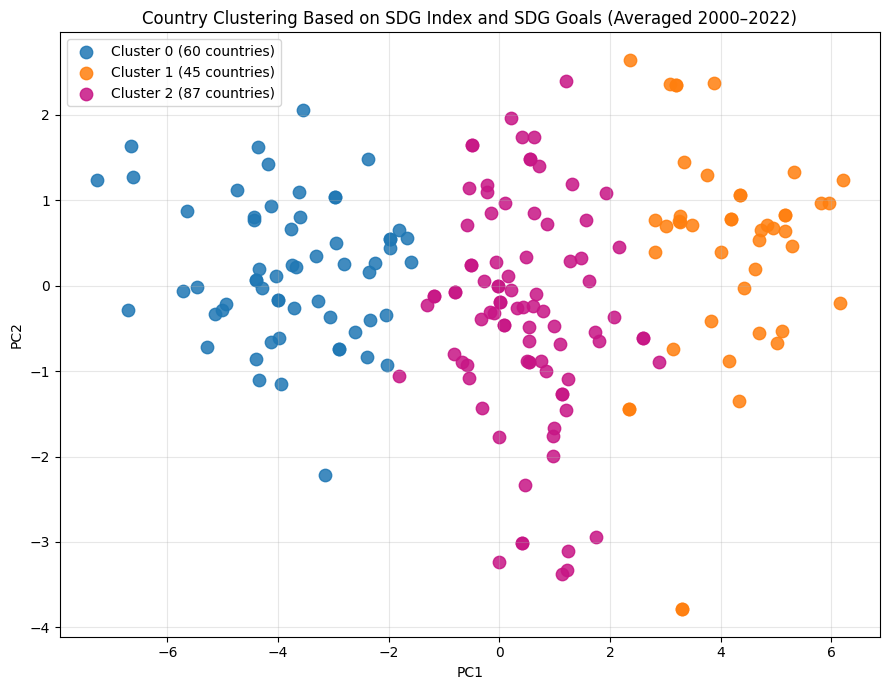

=== Countries per cluster ===

Cluster 0:
['Afghanistan', 'Andorra', 'Angola', 'Bangladesh', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Djibouti', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Haiti', 'India', 'Iraq', 'Kenya', 'Kiribati', 'Lao PDR', 'Lesotho', 'Liberia', 'Libya', 'Liechtenstein', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Myanmar', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Papua New Guinea', 'Rwanda', 'Saint Kitts and Nevis', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Somalia', 'South Sudan', 'Sudan', 'Syrian Arab Republic', 'Tanzania', 'Togo', 'Tuvalu', 'Uganda', 'Yemen, Rep.', 'Zambia', 'Zimbabwe']

Cluster 1:
['Australia', 'Austria', 'Belarus', 'Belgium', 'Canada', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Equatorial Guinea', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Icel

In [6]:
# Load data

df = pd.read_csv("run_31_reduced.csv")

# Identify all SDG columns
sdg_cols = ["sdg_index_score"] + [f"goal_{i}_score" for i in range(1, 17)]

# 1. Collapse SDG scores to country averages
country_sdg = (
    df[["country"] + sdg_cols]
    .dropna()
    .groupby("country")
    .mean()
    .reset_index()
)

X = country_sdg[sdg_cols].to_numpy()

# 2. Standardize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3. KMeans clustering (choose k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
country_sdg["cluster"] = kmeans.fit_predict(X_scaled)

# 4. PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

country_sdg["PC1"] = X_pca[:, 0]
country_sdg["PC2"] = X_pca[:, 1]

# 5. Plot clustering

cluster_colors = {
    0: "#1f77b4",   # blue
    1: "#ff7f0e",   # orange
    2: "#C71585",   # dark pink
}

plt.figure(figsize=(9,7))

for c in sorted(country_sdg["cluster"].unique()):
    sub = country_sdg[country_sdg["cluster"] == c]
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=80,
        alpha=0.85,
        color=cluster_colors[c],
        label=f"Cluster {c} ({len(sub)} countries)"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Clustering Based on SDG Index and SDG Goals (Averaged 2000–2022)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# 6. Print country lists and mean SDG scores per cluster
print("=== Countries per cluster ===")
for c in sorted(country_sdg["cluster"].unique()):
    print(f"\nCluster {c}:")
    print(country_sdg[country_sdg["cluster"] == c]["country"].tolist())

print("\n=== Mean SDG performance per cluster ===")
print(
    country_sdg.groupby("cluster")[sdg_cols]
    .mean()
    .round(2)
)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- settings ---
PATH = "run_31_reduced_with_continent.csv"
year_ref = 2020                 # choose reference year for cross-section
REGION_COL = "continent"        # change to your actual column name, e.g. "region"

# --- load and subset ---
df = pd.read_csv(PATH)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

vars_needed = ["goal_16_score", "political_stability_judge_score", REGION_COL]
sub = df[df["year"] == year_ref].copy()
sub = sub.dropna(subset=vars_needed)

# --- global regression for Goal 16 ~ political stability ---
x = sub["political_stability_judge_score"].to_numpy(dtype=float)
y = sub["goal_16_score"].to_numpy(dtype=float)
b1, b0 = np.polyfit(x, y, 1)          # y = b1*x + b0

sub["pred"] = b1 * x + b0
sub["resid"] = y - sub["pred"]

# z-score of residuals to flag outliers in the *relationship*
sd = sub["resid"].std(ddof=1)
sub["z_resid"] = sub["resid"] / sd if sd and not np.isnan(sd) else 0
outliers = sub[sub["z_resid"].abs() > 2]   # |z| > 2 as outliers

# --- plot: pattern (by continent) + outliers ---
fig, ax = plt.subplots(figsize=(8, 6))

# 1) scatter coloured by region/continent
for reg, g in sub.groupby(REGION_COL):
    ax.scatter(
        g["political_stability_judge_score"],
        g["goal_16_score"],
        alpha=0.6,
        s=35,
        label=str(reg)
    )

# 2) global regression line
xx = np.linspace(x.min(), x.max(), 200)
ax.plot(xx, b1*xx + b0, linewidth=2, label="Global fit")

# 3) highlight outliers with a halo
if not outliers.empty:
    ax.scatter(
        outliers["political_stability_judge_score"],
        outliers["goal_16_score"],
        facecolors="none",
        edgecolors="black",
        s=120,
        linewidths=1.5,
        label="Outliers (|z-resid| > 2)"
    )

ax.set_title(f"Goal 16 vs political stability ({year_ref})\nPatterns by {REGION_COL} and outliers in the relation")
ax.set_xlabel("Political stability (LLM score)")
ax.set_ylabel("SDG Goal 16 score")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

# Optional: print correlation by region to describe patterns in text
corr_by_region = (
    sub.groupby(REGION_COL)[["goal_16_score", "political_stability_judge_score"]]
      .corr()
      .unstack()
      .iloc[:, 1]   # correlation between the two variables
      .rename("corr_goal16_stability")
      .sort_values(ascending=False)
)

print("\nCorrelation of Goal 16 vs political stability by region:")
print(corr_by_region.to_string())
